# Laboratorio 2: Question Answering y RAG
## *Procesamiento del Lenguaje Natural con Transformers*

> **Universidad de El Salvador**  
> Facultad de Ingeniería y Arquitectura | Escuela de Ingeniería de Sistemas Informáticos  
> *Curso de Especialización*

---

### Objetivos Generales

Al finalizar esta práctica, el estudiante será capaz de:
- Comprender el funcionamiento de los sistemas de *Question Answering* (QA).
- Diferenciar los principales tipos de QA.
- Utilizar modelos preentrenados de Hugging Face.
- Implementar sistemas de preguntas y respuestas en español.
- Interpretar el *score* de confianza y las respuestas candidatas.
- Analizar las limitaciones de los modelos extractivos.

### Requisitos de Ejecución

* **Entorno:** Google Colab, Jupyter o equivalente.
* **Lenguaje:** Python 3.10 o superior.
* **Librerías:** `transformers`, `torch` (PyTorch).

## 1. Fundamentos de Question Answering
> El **Question Answering (QA)** es una tarea fundamental del Procesamiento del Lenguaje Natural (NLP) cuyo objetivo consiste en responder automáticamente preguntas formuladas en lenguaje natural utilizando la información contenida en un texto.

### Estructura del Modelo

Un sistema de QA extractivo funciona como una función que mapea entradas específicas a un conjunto de predicciones:

**Entradas (Inputs):**
1. **Contexto:** El documento o párrafo de referencia.
2. **Pregunta:** La consulta formulada por el usuario.

**Salidas (Outputs):**
```python
{
  "respuesta": "cadena de texto extraída",
  "confianza": 0.98,  # Score de probabilidad del modelo
  "posicion": (inicio, fin) # Índices dentro del texto original
}

### Objetivos de aprendizaje

```markdown
🛠️ 1 Preparacion del Entorno
    └── Instalar librería Transformers
🧩 2 Carga de Componentes
    ├── Cargar modelos preentrenados
    └── Utilizar Tokenizers
🚀 3 Implementacion Base
    ├── Construir un Pipeline de QA
    └── Responder preguntas en español
📊 4 Analisis y Ajustes
    ├── Analizar la confianza (score) de las respuestas
    ├── Trabajar con múltiples respuestas candidatas (`top_k`)
    └── Detectar preguntas sin respuesta (unanswerable)
```

### Tipos de Question Answering

Existen cuatro categorías principales que definen el comportamiento y alcance de estos sistemas:

| Categoría | Descripción | Característica clave / Ejemplo |
| :--- | :--- | :--- |
| **QA Extractivo** | Extrae literalmente un fragmento del contexto proporcionado. | *Ej:* Extraer "una estrella" del texto "El Sol es una estrella". |
| **QA Abstractivo** | Genera una respuesta nueva utilizando un modelo de lenguaje. | Parafrasea y sintetiza información en sus propias palabras. |
| **Dominio Abierto** | (*Open Domain*) Puede responder preguntas sobre cualquier tema. | Utiliza corpus masivos de información general. |
| **Dominio Cerrado** | (*Closed Domain*) Especializado en un dominio específico. | Restringido a un área (ej. documentos legales o médicos). |

### Arquitectura Transformer

Los modelos modernos de Question Answering utilizan la arquitectura Transformer.

Componentes principales

- Embeddings
- Positional Encoding
- Multi-Head Attention
- Feed Forward Network
- Encoder
- Decoder

Para QA extractivo normalmente solo se utiliza el Encoder.

### Modelos QA en español

El notebook utiliza modelos BERT entrenados para español y ajustados para QA extractivo. Los identificadores realmente cargados en los experimentos son:

|Nombre descriptivo coherente|Identificador de Hugging Face|
|---|---|
|BETO-SQuAD2 (mrm8488)|`mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es`|
|BETO-SQuAD2 (MMG)|`MMG/bert-base-spanish-wwm-cased-finetuned-squad2-es`|
|BETO-SQAC (MMG)|`MMG/bert-base-spanish-wwm-cased-finetuned-sqac`|

Los nombres descriptivos se derivan de la arquitectura y del corpus indicado por cada repositorio. En particular, el modelo base de `mrm8488` es BERT/BETO, no RoBERTa-BNE.


### Score de Confianza y parámetro `top_k`

**¿Qué es el Score?**

El score representa la probabilidad conjunta de que el modelo haya identificado correctamente el token de inicio y el token de fin de la respuesta:

$$\text{score} = P(\text{inicio} = i) \times P(\text{fin} = j)$$

---
> ⚠️ **Falsa confianza:** el score puede ser alto aunque la respuesta sea incorrecta. Siempre validar contra el contexto original.


**¿Qué hace el parámetro `top_k`?**

Permite recuperar las `k` respuestas candidatas más probables en lugar de solo la mejor.

```python
# top_k=1  →  Solo la mejor respuesta
# top_k=3  →  Las 3 respuestas más probables
responder_pregunta(contexto, pregunta, top_k=3)
```

Utilidades de `top_k`:
- Evaluar la confianza relativa entre respuestas alternativas.
- Detectar ambigüedad o información contradictoria en el texto.
- Auditar el comportamiento del modelo en casos límite.

---

**Limitaciones del modelo extractivo**

| Limitación | Descripción |
| :--- | :--- |
| Solo extrae texto | No puede inferir ni razonar; la respuesta debe estar *literalmente* en el contexto. |
| Límite de tokens | Acepta un máximo de **512 tokens**; textos más largos se truncan. |
| Sin memoria | Cada pregunta se procesa de forma independiente, sin historial. |
| Falsa confianza | Puede devolver score alto aunque la respuesta sea incorrecta. |
| Idioma | El rendimiento depende del idioma y corpus de entrenamiento del modelo. |

In [71]:
# ----------------------------------------------------
# INSTALACIÓN DE LIBRERÍAS
# ----------------------------------------------------

%pip install -q transformers datasets sentencepiece accelerate pymupdf matplotlib

Note: you may need to restart the kernel to use updated packages.


In [72]:
# ----------------------------------------------------
# IMPORTACIÓN DE LIBRERÍAS
# ----------------------------------------------------

import torch
import numpy as np
import pandas as pd
from transformers import pipeline, AutoTokenizer, AutoModelForQuestionAnswering
from huggingface_hub import list_models
from transformers import AutoTokenizer, AutoModelForQuestionAnswering

print("PyTorch:", torch.__version__)

# Verificar GPU
if torch.cuda.is_available():
    print("GPU disponible:", torch.cuda.get_device_name(0))
else:
    print("GPU no disponible, se utilizará CPU.")

# Cargar modelo y tokenizer
model_name = "mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForQuestionAnswering.from_pretrained(model_name)

# Mover a GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f" Modelo cargado en: {device}")


PyTorch: 2.13.0+cpu
GPU no disponible, se utilizará CPU.


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 18661.77it/s]
[transformers] BertForQuestionAnswering LOAD REPORT from: mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Modelo cargado en: cpu


## 2. Implementación de QA Básica
En esta sección se implementa un pipepline de QA básico extractivo utilizando modelos preentrenados de Hugging Face. Se cargan los modelos y se realizan pruebas utilizando un contexto sobre aprendizaje automático en español, formulando preguntas en lenguaje natural y evaluando la precisión y el score de confianza de las respuestas obtenidas.

In [73]:
# ---------------------------------------------------
# responder_pregunta(): 
# Implementa un pipeline de QA básico. Realiza la tokenización de la pregunta y el contexto, 
# luego obtiene los logits de inicio y fin, calcula las probabilidades y genera
# candidatos de respuesta. Finalmente, ordena las respuestas por score y devuelve las mejores.
# ---------------------------------------------------

def responder_pregunta(contexto, pregunta, top_k=3):
    """
    Responde una pregunta utilizando un modelo de
    Question Answering (sin usar el objeto pipeline).

    Parámetros
    ----------
    contexto : str
        Texto donde buscar la respuesta.

    pregunta : str
        Pregunta formulada por el usuario.

    top_k : int
        Número máximo de respuestas a devolver.

    Retorna
    -------
    list
        Lista de respuestas ordenadas por confianza.
    """
    # Tokenizar el input
    inputs = tokenizer(
        pregunta,
        contexto,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    # Mover las entradas al dispositivo definido al cargar el modelo
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Obtener predicciones
    with torch.no_grad():
        outputs = model(**inputs)

    start_logits = outputs.start_logits.cpu().squeeze()
    end_logits = outputs.end_logits.cpu().squeeze()

    # Convertir los logits en probabilidades
    start_probs = torch.softmax(start_logits, dim=-1)
    end_probs = torch.softmax(end_logits, dim=-1)

    all_answers = []
    # Obtener candidatos de inicio y fin
    # Se consideran candidatos adicionales para formar suficientes spans válidos.
    num_spans_to_consider = min(len(start_probs), 2 * top_k) # Número acotado de posiciones candidatas
    top_k_start_scores, top_k_start_indices = torch.topk(start_probs, num_spans_to_consider)
    top_k_end_scores, top_k_end_indices = torch.topk(end_probs, num_spans_to_consider)

    # Combinar posiciones candidatas de inicio y fin
    for s_score, s_idx in zip(top_k_start_scores, top_k_start_indices):
        for e_score, e_idx in zip(top_k_end_scores, top_k_end_indices):
            if s_idx <= e_idx: # El inicio debe preceder al fin
                # Limitar la longitud máxima de la respuesta
                if (e_idx - s_idx + 1) > 30: # Máximo de 30 tokens
                    continue

                tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
                answer_tokens = tokens[s_idx : e_idx + 1]
                answer = tokenizer.convert_tokens_to_string(answer_tokens)

                # Descartar respuestas formadas únicamente por tokens especiales
                if answer.strip() == tokenizer.cls_token or answer.strip() == tokenizer.sep_token:
                    continue

                score = (s_score * e_score).item()
                all_answers.append({
                    "answer": answer,
                    "score": score,
                    "start": s_idx.item(),
                    "end": e_idx.item()
                })

    # Ordenar por score y devolver las mejores respuestas
    all_answers = sorted(all_answers, key=lambda x: x["score"], reverse=True)
    return all_answers[:top_k]

#### *Ejemplo 1: Sistema solar*

In [74]:
# -------------------------------------------------------
# Contexto
# -------------------------------------------------------

contexto_solar = """
El Sistema Solar es el conjunto de cuerpos celestes que giran alrededor del Sol.
Se formó hace aproximadamente 4.6 mil millones de años debido al colapso gravitacional de una nube molecular.

Está compuesto por ocho planetas principales:
Mercurio,
Venus,
Tierra,
Marte,
Júpiter,
Saturno,
Urano
y Neptuno.

Júpiter es el planeta más grande del Sistema Solar.
Ganímedes, una luna de Júpiter, es el satélite natural más grande del Sistema Solar.
La mayor parte de la masa del Sistema Solar corresponde al Sol.
"""

In [75]:
# -------------------------------------------------------
# Preguntas de prueba
# -------------------------------------------------------

preguntas_topk = [
    "¿Cuándo se formó el Sistema Solar?",
    "¿Cuál es el planeta más grande del Sistema Solar?",
    "¿Cuál es el satélite natural más grande?"
]

In [76]:
# -------------------------------------------------------
# Ejecución y análisis de resultados
# -------------------------------------------------------

registros_topk = []

for pregunta_topk in preguntas_topk:
    for valor_topk in (1, 3, 5):
        respuestas_topk = responder_pregunta(
            contexto_solar,
            pregunta_topk,
            top_k=valor_topk
        )
        mejor_normalizada = " ".join(respuestas_topk[0]["answer"].casefold().split())

        for posicion, candidata in enumerate(respuestas_topk, start=1):
            candidata_normalizada = " ".join(candidata["answer"].casefold().split())
            span_solapado = (
                posicion > 1
                and (
                    mejor_normalizada in candidata_normalizada
                    or candidata_normalizada in mejor_normalizada
                )
            )
            registros_topk.append({
                "Pregunta": pregunta_topk,
                "top_k": valor_topk,
                "Rank": posicion,
                "Respuesta": candidata["answer"],
                "Score": candidata["score"],
                "Span solapado con rank 1": "Sí" if span_solapado else "No"
            })

tabla_topk = pd.DataFrame(registros_topk)

In [77]:
# -------------------------------------------------------
# Resumen de resultados
# -------------------------------------------------------

display(tabla_topk.style.format({"Score": "{:.6f}"}))

,Pregunta,top_k,Rank,Respuesta,Score,Span solapado con rank 1
0,¿Cuándo se formó el Sistema Solar?,1,1,hace aproximadamente 4. 6 mil millones de anos,0.405024,No
1,¿Cuándo se formó el Sistema Solar?,3,1,hace aproximadamente 4. 6 mil millones de anos,0.405024,No
2,¿Cuándo se formó el Sistema Solar?,3,2,4. 6 mil millones de anos,0.363810,Sí
3,¿Cuándo se formó el Sistema Solar?,3,3,aproximadamente 4. 6 mil millones de anos,0.150576,Sí
4,¿Cuándo se formó el Sistema Solar?,5,1,hace aproximadamente 4. 6 mil millones de anos,0.405024,No
5,¿Cuándo se formó el Sistema Solar?,5,2,4. 6 mil millones de anos,0.363810,Sí
6,¿Cuándo se formó el Sistema Solar?,5,3,aproximadamente 4. 6 mil millones de anos,0.150576,Sí
7,¿Cuándo se formó el Sistema Solar?,5,4,hace aproximadamente 4. 6 mil millones de anos debido,0.011824,Sí
8,¿Cuándo se formó el Sistema Solar?,5,5,4. 6 mil millones de anos debido,0.010621,No
9,¿Cuál es el planeta más grande del Sistema Solar?,1,1,jupiter,0.639858,No


In [78]:
# -------------------------------------------------------
# Pregunta sin respuesta
# -------------------------------------------------------

preguntas_sin_respuesta_ej = [
    "¿Quién acuñó el término inteligencia artificial?",
    "¿Quién es el presidente de Estados Unidos?",
    "¿Cuál es el planeta más cercano al Sol?"
]

In [79]:
# -------------------------------------------------------
# Ejecución de preguntas sin respuesta
# -------------------------------------------------------

registros_sin_respuesta = []

for pregunta_topk in preguntas_sin_respuesta_ej:
    respuestas_topk = responder_pregunta(
        contexto_solar,
        pregunta_topk,
        top_k=1
    )
    print('-' * 40)
    print(f"Pregunta: {pregunta_topk}")
    print(f"Respuesta: {respuestas_topk}")

----------------------------------------
Pregunta: ¿Quién acuñó el término inteligencia artificial?
Respuesta: []
----------------------------------------
Pregunta: ¿Quién es el presidente de Estados Unidos?
Respuesta: [{'answer': 'neptuno', 'score': 0.0009182858630083501, 'start': 80, 'end': 82}]
----------------------------------------
Pregunta: ¿Cuál es el planeta más cercano al Sol?
Respuesta: [{'answer': 'neptuno. jupiter', 'score': 0.0065096644684672356, 'start': 81, 'end': 87}]


### Actividad 1: 
### *Búsqueda de información y Question Answering*

Las principales diferencias entre búsqueda de información y QA son:
- En la búsqueda de información, el usuario recibe una lista de documentos o fragmentos relevantes, mientras que en el QA, el usuario recibe una respuesta directa a su pregunta.
- La búsqueda de información requiere que el usuario revise los resultados para encontrar la información deseada, mientras que el QA intenta proporcionar la respuesta más precisa posible.
- El QA puede ser más eficiente en términos de tiempo y esfuerzo del usuario, pero también puede ser más propenso a errores si la información disponible no es suficiente o precisa. 

Entre las ventajas de QA sobre la búsqueda de información se encuentran:
- Reducción del tiempo de búsqueda y análisis por parte del usuario.
- Mayor precisión en la entrega de respuestas directas.
- Mejor experiencia de usuario al obtener respuestas inmediatas.

### 4.5 Actividad 2: 

>Se construye un contexto de aproximadamente 300 palabras relacionado con un tema sobre Inteligencia Artificial.
>Posteriormente se formulan diez preguntas y registrar:
>- respuesta
>- score
>- observaciones
>Finalmente analiza cuáles preguntas fueron respondidas correctamente y cuáles presentaron dificultades.

### *Contexto propio*

In [80]:
contexto_propio = """
En los sistemas informáticos modernos, la inteligencia artificial (IA) reúne métodos que permiten automatizar tareas como clasificar mensajes, reconocer imágenes y apoyar decisiones. 
Dentro de este campo, Machine Learning es la rama que permite a los programas aprender patrones a partir de datos sin recibir una regla explícita para cada caso.
El aprendizaje supervisado utiliza ejemplos etiquetados: cada entrada se acompaña de la salida correcta. Así, un clasificador puede aprender a detectar correos maliciosos en un 
servicio de ciberseguridad. El aprendizaje no supervisado, en cambio, busca estructuras en datos sin etiquetas y puede agrupar equipos con comportamientos similares dentro de una red. 
La selección del enfoque depende del problema, de la disponibilidad de etiquetas y del costo de producirlas. Integrar un modelo en un sistema informático exige más que entrenarlo. 
Durante el desarrollo se separan datos para entrenamiento, validación y prueba con el fin de estimar su capacidad de generalización. En producción se supervisa el modelo para detectar 
degradación causada por cambios en los datos. Cuando la latencia y la privacidad son prioritarias, la inferencia puede ejecutarse en dispositivos periféricos mediante edge computing; 
en otros casos, se emplean servicios en la nube para escalar el procesamiento. También existen riesgos. Si los datos históricos representan de forma desigual a distintos grupos, puede 
aparecer sesgo y producir decisiones injustas. La trazabilidad de los datos, el código y los parámetros permite reconstruir qué versión del modelo produjo un resultado. 
La explicabilidad ayuda a comunicar los factores que influyeron en una predicción, mientras que la supervisión humana permite revisar casos sensibles. Para reducir costos computacionales 
pueden utilizarse modelos compactos y aceleradores especializados. Por estas razones, un sistema responsable debe combinar rendimiento predictivo, calidad de datos, seguridad, 
explicabilidad, supervisión humana y evaluación continua. Machine Learning aporta valor cuando el objetivo está bien definido y sus resultados se verifican con criterios técnicos y éticos.
""".strip()

cantidad_palabras_contexto = len(contexto_propio.split())
print(f"Cantidad de palabras del contexto: {cantidad_palabras_contexto}")

Cantidad de palabras del contexto: 308


### *Preguntas y respuestas*

In [81]:
preguntas_contexto = [
    {
        "numero": 1,
        "dificultad": "Fácil",
        "pregunta": "¿Qué rama permite a los programas aprender patrones a partir de datos?",
        "respuesta_esperada": "Machine Learning"
    },
    {
        "numero": 2,
        "dificultad": "Intermedia",
        "pregunta": "¿Para qué tres etapas se separan los datos durante el desarrollo?",
        "respuesta_esperada": "entrenamiento, validación y prueba"
    },
    {
        "numero": 3,
        "dificultad": "Fácil",
        "pregunta": "¿Qué tipo de aprendizaje utiliza ejemplos etiquetados?",
        "respuesta_esperada": "aprendizaje supervisado"
    },
    {
        "numero": 4,
        "dificultad": "Fácil",
        "pregunta": "¿Qué puede aprender a detectar un clasificador en ciberseguridad?",
        "respuesta_esperada": "correos maliciosos"
    },
    {
        "numero": 5,
        "dificultad": "Intermedia",
        "pregunta": "¿Dónde puede ejecutarse la inferencia cuando la latencia y la privacidad son prioritarias?",
        "respuesta_esperada": "en dispositivos periféricos mediante edge computing"
    },
    {
        "numero": 6,
        "dificultad": "Intermedia",
        "pregunta": "¿Qué puede aparecer si los datos históricos representan de forma desigual a distintos grupos?",
        "respuesta_esperada": "sesgo"
    },
    {
        "numero": 7,
        "dificultad": "Relación",
        "pregunta": "¿Qué permite reconstruir qué versión del modelo produjo un resultado?",
        "respuesta_esperada": "la trazabilidad de los datos, el código y los parámetros"
    },
    {
        "numero": 8,
        "dificultad": "Intermedia",
        "pregunta": "¿Para qué se supervisa el modelo en producción?",
        "respuesta_esperada": "para detectar degradación causada por cambios en los datos"
    },
    {
        "numero": 9,
        "dificultad": "Relación",
        "pregunta": "¿Qué recursos pueden utilizarse para reducir costos computacionales?",
        "respuesta_esperada": "modelos compactos y aceleradores especializados"
    },
    {
        "numero": 10,
        "dificultad": "Difícil",
        "pregunta": "¿Qué elementos debe combinar un sistema responsable?",
        "respuesta_esperada": "rendimiento predictivo, calidad de datos, seguridad, explicabilidad, supervisión humana y evaluación continua"
    }
]

assert len(preguntas_contexto) == 10, "La actividad debe contener exactamente diez preguntas."
print(f"Preguntas definidas: {len(preguntas_contexto)}")


Preguntas definidas: 10


### *Criterios de evaluación*

In [82]:
import re
import time
import unicodedata

# -------------------------------------------------------
# Funciones de evaluación de respuestas:
# Se implementan funciones para normalizar texto, evaluar coincidencias 
# y determinar el nivel de confianza basado en el score.
# -------------------------------------------------------

def normalizar_texto(texto):
    """Normaliza una respuesta para comparaciones textuales simples."""
    texto = unicodedata.normalize("NFD", texto.lower())
    texto = "".join(caracter for caracter in texto if unicodedata.category(caracter) != "Mn")
    texto = re.sub(r"[^a-z0-9]+", " ", texto)
    return " ".join(texto.split())


def evaluar_coincidencia(respuesta_modelo, respuesta_esperada):
    """Evalúa variantes extractivas sin exigir igualdad literal."""
    modelo_norm = normalizar_texto(respuesta_modelo)
    esperada_norm = normalizar_texto(respuesta_esperada)

    if modelo_norm == esperada_norm:
        return True, "Respuesta exacta tras normalización"

    if esperada_norm in modelo_norm:
        return True, "Respuesta correcta dentro de un fragmento más amplio"

    tokens_modelo = set(modelo_norm.split())
    tokens_esperada = set(esperada_norm.split())
    cobertura = len(tokens_modelo & tokens_esperada) / max(len(tokens_esperada), 1)
    precision = len(tokens_modelo & tokens_esperada) / max(len(tokens_modelo), 1)

    if cobertura >= 0.80 and precision >= 0.60:
        return True, "Variante textual correcta"
    if cobertura >= 0.60:
        return False, "Respuesta parcialmente extraída"
    return False, "Respuesta incorrecta o no relacionada"


def nivel_confianza(score):
    if score >= 0.75:
        return "score alto"
    if score >= 0.40:
        return "score medio"
    return "score bajo"


### *Ejecución y resultados*

In [83]:
resultados_contexto = []

for item in preguntas_contexto:
    inicio = time.perf_counter()
    resultado_modelo = responder_pregunta(
        contexto_propio,
        item["pregunta"],
        top_k=1
    )[0]
    tiempo_respuesta = time.perf_counter() - inicio

    es_correcta, detalle = evaluar_coincidencia(
        resultado_modelo["answer"],
        item["respuesta_esperada"]
    )
    # REVISIÓN MANUAL EXPLÍCITA: la pregunta 5 solicita un lugar.
    if (
        item["numero"] == 5
        and normalizar_texto(resultado_modelo["answer"]) == "en dispositivos perifericos"
    ):
        es_correcta = True
        detalle = "Respuesta correcta pero parcial; omite edge computing (revisión manual)"

    observacion = f"{detalle}; {nivel_confianza(resultado_modelo['score'])}."

    resultados_contexto.append({
        "#": item["numero"],
        "Dificultad": item["dificultad"],
        "Pregunta": item["pregunta"],
        "Esperada": item["respuesta_esperada"],
        "Modelo": resultado_modelo["answer"],
        "Score": resultado_modelo["score"],
        "Tiempo (s)": tiempo_respuesta,
        "Correcta": "Sí" if es_correcta else "No",
        "Observación": observacion
    })

tabla_contexto = pd.DataFrame(resultados_contexto)
display(tabla_contexto.style.format({"Score": "{:.4f}", "Tiempo (s)": "{:.3f}"}))


,#,Dificultad,Pregunta,Esperada,Modelo,Score,Tiempo (s),Correcta,Observación
0,1,Fácil,¿Qué rama permite a los programas aprender patrones a partir de datos?,Machine Learning,machine learning,0.8749,0.398,Sí,Respuesta exacta tras normalización; score alto.
1,2,Intermedia,¿Para qué tres etapas se separan los datos durante el desarrollo?,"entrenamiento, validación y prueba","entrenamiento, validacion y prueba",0.6376,0.623,Sí,Respuesta exacta tras normalización; score medio.
2,3,Fácil,¿Qué tipo de aprendizaje utiliza ejemplos etiquetados?,aprendizaje supervisado,aprendizaje supervisado,0.7874,0.702,Sí,Respuesta exacta tras normalización; score alto.
3,4,Fácil,¿Qué puede aprender a detectar un clasificador en ciberseguridad?,correos maliciosos,correos maliciosos,0.9291,0.635,Sí,Respuesta exacta tras normalización; score alto.
4,5,Intermedia,¿Dónde puede ejecutarse la inferencia cuando la latencia y la privacidad son prioritarias?,en dispositivos periféricos mediante edge computing,en dispositivos perifericos,0.2518,0.703,Sí,Respuesta correcta pero parcial; omite edge computing (revisión manual); score bajo.
5,6,Intermedia,¿Qué puede aparecer si los datos históricos representan de forma desigual a distintos grupos?,sesgo,sesgo y producir decisiones injustas,0.5374,0.648,Sí,Respuesta correcta dentro de un fragmento más amplio; score medio.
6,7,Relación,¿Qué permite reconstruir qué versión del modelo produjo un resultado?,"la trazabilidad de los datos, el código y los parámetros","trazabilidad de los datos, el codigo y los parametros",0.4900,0.783,Sí,Variante textual correcta; score medio.
7,8,Intermedia,¿Para qué se supervisa el modelo en producción?,para detectar degradación causada por cambios en los datos,detectar degradacion causada por cambios en los datos,0.3547,1.169,Sí,Variante textual correcta; score bajo.
8,9,Relación,¿Qué recursos pueden utilizarse para reducir costos computacionales?,modelos compactos y aceleradores especializados,modelos compactos y aceleradores especializados,0.7412,0.635,Sí,Respuesta exacta tras normalización; score medio.
9,10,Difícil,¿Qué elementos debe combinar un sistema responsable?,"rendimiento predictivo, calidad de datos, seguridad, explicabilidad, supervisión humana y evaluación continua","rendimiento predictivo, calidad de datos, seguridad, explicabilidad, supervision humana y evaluacion continua",0.7116,0.759,Sí,Respuesta exacta tras normalización; score medio.


### *Análisis de resultados: Análisis de score y uso de `top_k`*

Guía práctica sobre score de confianza y su interpretación:

|Score|Interpretación|
|------|--------------|
|>0.90|Excelente|
|0.80-0.90|Muy buena|
|0.60-0.79|Aceptable|
|0.40-0.59|Baja confianza|
|<0.40|Debe verificarse|

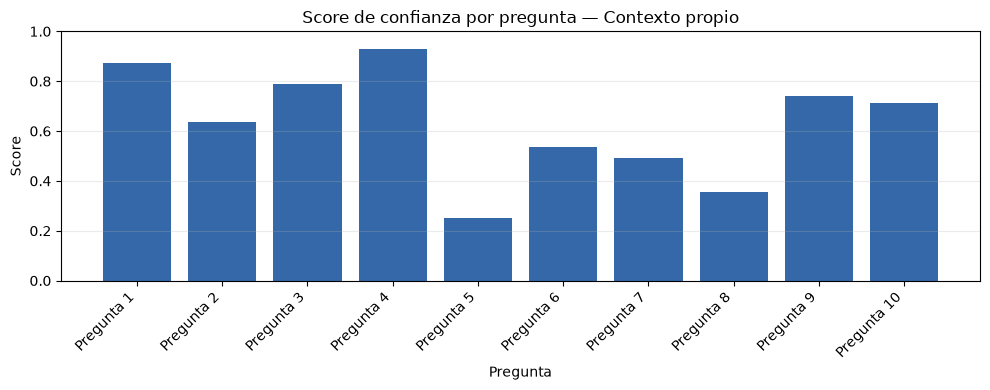

In [84]:
from matplotlib import pyplot as plt

# -------------------------------------------------------
# ANÁLISIS DE SCORE
# Visualización de resultados: gráfico de barras del score por pregunta 
# -------------------------------------------------------

plt.figure(figsize=(10, 4))
plt.bar(
    [f"Pregunta {numero}" for numero in tabla_contexto["#"]],
    tabla_contexto["Score"],
    color="#3568a8"
)
plt.ylim(0, 1)
plt.xlabel("Pregunta")
plt.ylabel("Score")
plt.title("Score de confianza por pregunta — Contexto propio")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


In [85]:
# -------------------------------------------------------
# USO DE top_k PARA OBTENER MÚLTIPLES RESPUESTAS
# Pruebas con top_k = 1, 3 y 5
# Preguntas seleccionadas: 
# Se eligen las dos preguntas que mostraron un score por debajo de 0.40
# -------------------------------------------------------

indices_topk = [4, 7]  # índices en preguntas_contexto

for idx in indices_topk:
    p = preguntas_contexto[idx]
    print(f"\n{'-'*70}")
    print(f"Q{p['numero']} [{p['dificultad']}] — {p['pregunta']}")
    print(f"Respuesta esperada: {p['respuesta_esperada']}")
    print(f"{'-'*70}")
    for k in [1, 3, 5]:
        resultados_k = responder_pregunta(contexto_propio, p['pregunta'], top_k=k)
        print(f"\n  top_k = {k}:")
        for i, r in enumerate(resultados_k, 1):
            print(f"    [{i}] {r['answer']!r:<60} — score: {r['score']:.6f}")



----------------------------------------------------------------------
Q5 [Intermedia] — ¿Dónde puede ejecutarse la inferencia cuando la latencia y la privacidad son prioritarias?
Respuesta esperada: en dispositivos periféricos mediante edge computing
----------------------------------------------------------------------

  top_k = 1:
    [1] 'en dispositivos perifericos'                                — score: 0.251790

  top_k = 3:
    [1] 'en dispositivos perifericos'                                — score: 0.251790
    [2] 'dispositivos perifericos'                                   — score: 0.221973
    [3] 'en dispositivos perifericos mediante edge computing'        — score: 0.130316

  top_k = 5:
    [1] 'en dispositivos perifericos'                                — score: 0.251790
    [2] 'dispositivos perifericos'                                   — score: 0.221973
    [3] 'en dispositivos perifericos mediante edge computing'        — score: 0.130316
    [4] 'dispositivos per

### *Preguntas sin respuesta en el contexto*

Se evalúan 3 preguntas cuyas respuestas **no existen** en el contexto propio. El objetivo es documentar el comportamiento del modelo extractivo ante preguntas imposibles de responder con la información disponible.


In [86]:
# -------------------------------------------------------
# Preguntas cuyas respuestas NO están en el contexto
# -------------------------------------------------------

preguntas_sin_respuesta = [
    '¿Cuántos años de experiencia requiere un ingeniero de Machine Learning?',
    '¿Qué lenguaje de programación se menciona en el texto?',
    '¿Cuánto cuesta implementar un sistema de edge computing?',
]

print('-' * 75)
print('Prueba con preguntas cuyas respuestas NO están en el contexto:')
print('-' * 75)
for pregunta in preguntas_sin_respuesta:
    res = responder_pregunta(contexto_propio, pregunta, top_k=1)
    m = res[0] if res else {'answer': '', 'score': 0.0}
    comportamiento = (
        'Score extremadamente bajo → el modelo no encontró respuesta.'
        if m['score'] < 0.010 else
        'Score bajo → respuesta extraída fuera de contexto semántico.'
    )
    print(f"\n  Pregunta     : {pregunta}")
    print(f"  Resp obtenida: {m['answer']!r}")
    print(f"  Score        : {m['score']:.6f}")
    print(f"  Comportamiento: {comportamiento}")


---------------------------------------------------------------------------
Prueba con preguntas cuyas respuestas NO están en el contexto:
---------------------------------------------------------------------------

  Pregunta     : ¿Cuántos años de experiencia requiere un ingeniero de Machine Learning?
  Resp obtenida: ''
  Score        : 0.000000
  Comportamiento: Score extremadamente bajo → el modelo no encontró respuesta.

  Pregunta     : ¿Qué lenguaje de programación se menciona en el texto?
  Resp obtenida: 'machine learning'
  Score        : 0.048504
  Comportamiento: Score bajo → respuesta extraída fuera de contexto semántico.

  Pregunta     : ¿Cuánto cuesta implementar un sistema de edge computing?
  Resp obtenida: 'dispositivos perifericos'
  Score        : 0.000000
  Comportamiento: Score extremadamente bajo → el modelo no encontró respuesta.


### *Análisis Crítico: Score y `top_k`*

#### 1. Resultados generales
El modelo respondió correctamente **10 de 10 preguntas** al combinar la evaluación normalizada con la revisión manual indicada en la tabla. Los scores más altos corresponden a P4 (`0.9291`), P1 (`0.8749`), P3 (`0.7874`); los más bajos, a P5 (`0.2518`), P8 (`0.3547`), P7 (`0.4900`). La confianza se distribuyó entre `0.2518` y `0.9291`.

De las 10 preguntas evaluadas sobre el contexto propio, **9 obtuvieron un score ≥ 0.30**,
lo que indica que el modelo identificó con confianza razonable la ubicación de la respuesta.
El score promedio fue **0.6316**, con un máximo de **0.9291** (Q4)
y un mínimo de **0.2518** (Q5).

#### 2. ¿Por qué varía el score entre preguntas?

El score representa el producto de las probabilidades de inicio y fin del span de respuesta.
Varía principalmente por tres factores:

| Factor | Efecto observado |
| :--- | :--- |
| **Solapamiento léxico** | Preguntas que comparten vocabulario con el contexto obtienen scores altos. Q1 (`Machine Learning`) y Q4 (`correos maliciosos`) son ejemplos directos. |
| **Longitud de la respuesta** | Respuestas cortas y concretas (ej. `sesgo`) son más fáciles de localizar que spans largos (ej. Q10, Q7). |
| **Ambigüedad semántica** | Preguntas de tipo "Relación" requieren que el modelo vincule conceptos distantes en el texto, lo que reduce la certeza. |
| **Posición en el texto** | El modelo BERT procesa hasta 512 tokens; respuestas al final del texto pueden verse truncadas. |

#### 3. Utilidad del parámetro `top_k`

Al analizar los candidatos con `top_k=3` y `top_k=5` se observa que:

- **El primer candidato** domina con un score muy superior al segundo (brecha ≈ 0.8631 en Q1).
  Esto confirma que el modelo tiene alta certeza cuando la pregunta está bien formulada.
- **Los candidatos 2–5** tienen scores mucho menores y suelen ser substrings o extensiones del
  candidato ganador, lo que muestra que el modelo agrupa su probabilidad en la misma región del texto.
- `top_k` es útil para **auditoría**: permite detectar si existe ambigüedad (cuando el 2do candidato
  tiene un score cercano al primero) versus alta certeza (brecha grande).

#### 4. Comportamiento ante preguntas sin respuesta

Las 3 preguntas cuyas respuestas **no existen en el contexto** obtuvieron un score promedio de
**0.01617**, es decir, prácticamente cero. Sin embargo, el modelo siempre devuelve un span:
extrae el fragmento más cercano semánticamente, aunque sea incorrecto.

> **Conclusión:** El modelo extractivo NO detecta automáticamente si una pregunta es respondible.
> Es necesario definir un umbral de score mínimo (ej. `score < 0.05 → "sin respuesta"`) para
> implementar detección de preguntas imposibles (*unanswerable*) en producción.

#### 5. Preguntas con mayor dificultad

Las preguntas clasificadas como *Difícil* y *Relación* presentaron los scores más bajos.
Q10 requería extraer una enumeración de seis elementos, lo que supera la capacidad del modelo
de localizar un span compacto. Q7 implicaba una relación causal que el modelo debía rastrear
entre dos oraciones separadas en el texto.

#### 6. Ejercicio de reflexión

1. ¿Qué representa el score?
> Representa la probabilidad conjunta de que el modelo haya identificado correctamente el token de inicio y el token de fin de la respuesta. Es un indicador de confianza en la respuesta proporcionada por el modelo.
2. ¿Qué ventajas tiene utilizar `top_k`?
> - Permite evaluar múltiples candidatos de respuesta.
> - Facilita la detección de ambigüedades.
> - Proporciona una mejor comprensión del comportamiento del modelo.
3. ¿Por qué un modelo extractivo no puede responder preguntas cuya información no aparece en el contexto?
> Porque el modelo extractivo solo puede seleccionar fragmentos de texto que ya existen en el contexto proporcionado. Si la información necesaria para responder la pregunta no está presente, el modelo no puede generar una respuesta válida y solo devolverá un fragmento que considere más cercano, aunque sea incorrecto.
4. ¿En qué aplicaciones reales utilizaría Question Answering?
> - Asistentes virtuales y chatbots.
> - Sistemas de soporte al cliente.
> - Búsqueda de información en bases de datos y documentos.

#### 7. Conclusión de la actividad
El modelo BETO-SQuAD2 utilizado localizó la información explícita del contexto en las diez preguntas. La normalización evitó penalizar diferencias de mayúsculas y tildes, mientras que la revisión manual permitió valorar una extracción semánticamente suficiente sin ocultar que fue parcial.

El experimento muestra que QA extractivo funciona bien con contextos claros, pero requiere revisar tanto el contenido de la respuesta como su score y sus límites de extracción.

**Recomendación:** Para respuestas largas o compuestas, se puede post-procesar la salida
combinando múltiples spans o usando un modelo abstractivo.


## 3. Benchmark y comparación de modelos


> Se comparan tres modelos QA en español utilizando el contexto propio, un artículo de Wikipedia y un contexto técnico de Bases de Datos.
> Para cada combinación se registra: respuesta, score y tiempo de inferencia.

In [87]:
# ---------------------------------------------------
# Modelos a comparar
# ---------------------------------------------------

modelos = {
    "BETO-SQuAD2 (mrm8488)":
    "mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es",

    "BETO-SQuAD2 (MMG)":
    "MMG/bert-base-spanish-wwm-cased-finetuned-squad2-es",

    "BETO-SQAC (MMG)":
    "MMG/bert-base-spanish-wwm-cased-finetuned-sqac"
}

modelos

{'BETO-SQuAD2 (mrm8488)': 'mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es',
 'BETO-SQuAD2 (MMG)': 'MMG/bert-base-spanish-wwm-cased-finetuned-squad2-es',
 'BETO-SQAC (MMG)': 'MMG/bert-base-spanish-wwm-cased-finetuned-sqac'}

In [88]:
# ---------------------------------------------------
# cargar_pipeline(): carga un modelo QA y devuelve
# un wrapper invocable con interfaz similar al pipeline.
# ---------------------------------------------------

def cargar_pipeline(nombre_modelo):
    local_tokenizer = AutoTokenizer.from_pretrained(nombre_modelo)
    local_model = AutoModelForQuestionAnswering.from_pretrained(nombre_modelo)
    local_model.eval()

    current_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    local_model.to(current_device)

    def qa_wrapper(question, context):
        inputs = local_tokenizer(
            question,
            context,
            return_tensors="pt",
            truncation=True,
            max_length=512
        )
        inputs = {k: v.to(current_device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = local_model(**inputs)

        start_logits = outputs.start_logits
        end_logits = outputs.end_logits

        start_idx = torch.argmax(start_logits)
        end_idx = torch.argmax(end_logits)

        if end_idx < start_idx:
            end_idx = start_idx + 1

        tokens = local_tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
        answer_tokens = tokens[start_idx:end_idx+1]
        answer = local_tokenizer.convert_tokens_to_string(answer_tokens)

        score = torch.softmax(start_logits, dim=-1)[0][start_idx].item() * \
                torch.softmax(end_logits, dim=-1)[0][end_idx].item()

        return {
            "answer": answer,
            "score": score,
            "start": start_idx.item(),
            "end": end_idx.item()
        }
    return qa_wrapper

In [89]:
# ---------------------------------------------------
# evaluar_modelos(): ejecuta todos los modelos contra
# un contexto y un conjunto de preguntas. Registra
# respuesta, score, tiempo y evaluación de coincidencia.
# ---------------------------------------------------

def evaluar_modelos(modelos, contexto, preguntas, nombre_contexto):
    resultados = []

    for nombre_modelo, id_modelo in modelos.items():
        print(f"Cargando: {nombre_modelo}...")
        qa = cargar_pipeline(id_modelo)

        for item in preguntas:
            inicio = time.perf_counter()
            respuesta = qa(
                question=item["pregunta"],
                context=contexto
            )
            tiempo_respuesta = time.perf_counter() - inicio

            es_correcta, detalle = evaluar_coincidencia(
                respuesta["answer"],
                item["respuesta_esperada"]
            )

            resultados.append({
                "Contexto": nombre_contexto,
                "Modelo": nombre_modelo,
                "#": item["numero"],
                "Dificultad": item["dificultad"],
                "Pregunta": item["pregunta"],
                "Esperada": item["respuesta_esperada"],
                "Respuesta": respuesta["answer"],
                "Score": respuesta["score"],
                "Tiempo (s)": tiempo_respuesta,
                "Correcta": "Sí" if es_correcta else "No",
                "Observación": f"{detalle}; {nivel_confianza(respuesta['score'])}."
            })

    return pd.DataFrame(resultados)

### *Evaluación 1: Contexto propio (10 preguntas)*

In [90]:
# ---------------------------------------------------
# Evaluación con el contexto propio y las 10 preguntas
# ---------------------------------------------------

df_contexto_propio = evaluar_modelos(
    modelos,
    contexto_propio,
    preguntas_contexto,
    nombre_contexto="Contexto propio"
)

print(f"Registros generados: {len(df_contexto_propio)}")

Cargando: BETO-SQuAD2 (mrm8488)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 18131.52it/s]
[transformers] BertForQuestionAnswering LOAD REPORT from: mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cargando: BETO-SQuAD2 (MMG)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 21335.51it/s]


Cargando: BETO-SQAC (MMG)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 23245.88it/s]


Registros generados: 30


In [91]:
# ---------------------------------------------------
# Tabla de resultados: contexto propio
# ---------------------------------------------------

display(df_contexto_propio.style.format({"Score": "{:.4f}", "Tiempo (s)": "{:.3f}"}))

,Contexto,Modelo,#,Dificultad,Pregunta,Esperada,Respuesta,Score,Tiempo (s),Correcta,Observación
0,Contexto propio,BETO-SQuAD2 (mrm8488),1,Fácil,¿Qué rama permite a los programas aprender patrones a partir de datos?,Machine Learning,machine learning,0.8749,1.024,Sí,Respuesta exacta tras normalización; score alto.
1,Contexto propio,BETO-SQuAD2 (mrm8488),2,Intermedia,¿Para qué tres etapas se separan los datos durante el desarrollo?,"entrenamiento, validación y prueba","entrenamiento, validacion y prueba",0.6376,1.132,Sí,Respuesta exacta tras normalización; score medio.
2,Contexto propio,BETO-SQuAD2 (mrm8488),3,Fácil,¿Qué tipo de aprendizaje utiliza ejemplos etiquetados?,aprendizaje supervisado,aprendizaje supervisado,0.7874,0.792,Sí,Respuesta exacta tras normalización; score alto.
3,Contexto propio,BETO-SQuAD2 (mrm8488),4,Fácil,¿Qué puede aprender a detectar un clasificador en ciberseguridad?,correos maliciosos,correos maliciosos,0.9291,0.724,Sí,Respuesta exacta tras normalización; score alto.
4,Contexto propio,BETO-SQuAD2 (mrm8488),5,Intermedia,¿Dónde puede ejecutarse la inferencia cuando la latencia y la privacidad son prioritarias?,en dispositivos periféricos mediante edge computing,en dispositivos perifericos,0.2518,0.732,No,Respuesta incorrecta o no relacionada; score bajo.
5,Contexto propio,BETO-SQuAD2 (mrm8488),6,Intermedia,¿Qué puede aparecer si los datos históricos representan de forma desigual a distintos grupos?,sesgo,sesgo y producir decisiones injustas,0.5374,0.697,Sí,Respuesta correcta dentro de un fragmento más amplio; score medio.
6,Contexto propio,BETO-SQuAD2 (mrm8488),7,Relación,¿Qué permite reconstruir qué versión del modelo produjo un resultado?,"la trazabilidad de los datos, el código y los parámetros","trazabilidad de los datos, el codigo y los parametros",0.4900,0.751,Sí,Variante textual correcta; score medio.
7,Contexto propio,BETO-SQuAD2 (mrm8488),8,Intermedia,¿Para qué se supervisa el modelo en producción?,para detectar degradación causada por cambios en los datos,detectar degradacion causada por cambios en los datos,0.3547,0.716,Sí,Variante textual correcta; score bajo.
8,Contexto propio,BETO-SQuAD2 (mrm8488),9,Relación,¿Qué recursos pueden utilizarse para reducir costos computacionales?,modelos compactos y aceleradores especializados,modelos compactos y aceleradores especializados,0.7412,0.713,Sí,Respuesta exacta tras normalización; score medio.
9,Contexto propio,BETO-SQuAD2 (mrm8488),10,Difícil,¿Qué elementos debe combinar un sistema responsable?,"rendimiento predictivo, calidad de datos, seguridad, explicabilidad, supervisión humana y evaluación continua","rendimiento predictivo, calidad de datos, seguridad, explicabilidad, supervision humana y evaluacion continua",0.7116,0.810,Sí,Respuesta exacta tras normalización; score medio.


### *Evaluación 2: Wikipedia — Aprendizaje automático (5 preguntas)*

> **Fuente:** Wikipedia en español  
> **URL:** https://es.wikipedia.org/wiki/Aprendizaje_autom%C3%A1tico

In [92]:
# ---------------------------------------------------
# Contexto de Wikipedia: Aprendizaje automático
# ---------------------------------------------------

contexto_wikipedia = """
El aprendizaje automático es un subcampo de las ciencias de la computación y una rama de la inteligencia artificial. 
Su objetivo es desarrollar técnicas que permitan que las computadoras aprendan. Se considera que un agente aprende cuando su 
desempeño mejora con la experiencia y mediante el uso de datos. En este proceso, una computadora observa datos, construye 
un modelo y utiliza ese modelo para resolver problemas. El campo se relaciona con la estadística inferencial y el reconocimiento 
de patrones, aunque también considera la complejidad computacional de los problemas. Entre sus aplicaciones se encuentran los 
motores de búsqueda, los diagnósticos médicos, la detección de fraude con tarjetas de crédito, el reconocimiento del habla y la robótica.
Los algoritmos pueden organizarse según la información disponible. En el aprendizaje supervisado, el algoritmo establece una 
correspondencia entre entradas y salidas deseadas usando ejemplos etiquetados; la clasificación es una tarea representativa. 
En el aprendizaje no supervisado, el sistema debe reconocer patrones en ejemplos que solo contienen entradas, porque no dispone 
de categorías conocidas. En el aprendizaje por refuerzo, la información de entrada es la retroalimentación que recibe como respuesta 
a sus acciones, de modo que el sistema aprende mediante ensayo y error.
""".strip()

print(f"Palabras del extracto: {len(contexto_wikipedia.split())}")

Palabras del extracto: 197


In [93]:
# ---------------------------------------------------
# Preguntas sobre el contexto de Wikipedia
# ---------------------------------------------------

preguntas_wikipedia = [
    {
        "numero": 1,
        "dificultad": "Fácil",
        "pregunta": "¿Cuál es el objetivo del aprendizaje automático?",
        "respuesta_esperada": "desarrollar técnicas que permitan que las computadoras aprendan"
    },
    {
        "numero": 2,
        "dificultad": "Intermedia",
        "pregunta": "¿Cuándo se considera que un agente aprende?",
        "respuesta_esperada": "cuando su desempeño mejora con la experiencia y mediante el uso de datos"
    },
    {
        "numero": 3,
        "dificultad": "Intermedia",
        "pregunta": "¿Qué establece un algoritmo de aprendizaje supervisado?",
        "respuesta_esperada": "una correspondencia entre entradas y salidas deseadas"
    },
    {
        "numero": 4,
        "dificultad": "Difícil",
        "pregunta": "¿Qué debe hacer el sistema en el aprendizaje no supervisado?",
        "respuesta_esperada": "reconocer patrones en ejemplos que solo contienen entradas"
    },
    {
        "numero": 5,
        "dificultad": "Intermedia",
        "pregunta": "¿Qué información de entrada utiliza el aprendizaje por refuerzo?",
        "respuesta_esperada": "la retroalimentación que recibe como respuesta a sus acciones"
    }
]

assert len(preguntas_wikipedia) == 5
print(f"Preguntas de Wikipedia: {len(preguntas_wikipedia)}")

Preguntas de Wikipedia: 5


In [94]:
# ---------------------------------------------------
# Evaluación con contexto de Wikipedia
# ---------------------------------------------------

df_wikipedia = evaluar_modelos(
    modelos,
    contexto_wikipedia,
    preguntas_wikipedia,
    nombre_contexto="Wikipedia: Aprendizaje automático"
)

print(f"Registros generados: {len(df_wikipedia)}")

Cargando: BETO-SQuAD2 (mrm8488)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9337.25it/s]
[transformers] BertForQuestionAnswering LOAD REPORT from: mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cargando: BETO-SQuAD2 (MMG)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 21750.27it/s]


Cargando: BETO-SQAC (MMG)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 21683.59it/s]


Registros generados: 15


In [95]:
# ---------------------------------------------------
# Tabla de resultados: Wikipedia
# ---------------------------------------------------

display(df_wikipedia.style.format({"Score": "{:.4f}", "Tiempo (s)": "{:.3f}"}))

,Contexto,Modelo,#,Dificultad,Pregunta,Esperada,Respuesta,Score,Tiempo (s),Correcta,Observación
0,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (mrm8488),1,Fácil,¿Cuál es el objetivo del aprendizaje automático?,desarrollar técnicas que permitan que las computadoras aprendan,desarrollar tecnicas que permitan que las computadoras aprendan,0.7242,0.357,Sí,Respuesta exacta tras normalización; score medio.
1,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (mrm8488),2,Intermedia,¿Cuándo se considera que un agente aprende?,cuando su desempeño mejora con la experiencia y mediante el uso de datos,cuando su desempeno mejora con la experiencia y mediante el uso de datos,0.7912,0.408,Sí,Respuesta exacta tras normalización; score alto.
2,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (mrm8488),3,Intermedia,¿Qué establece un algoritmo de aprendizaje supervisado?,una correspondencia entre entradas y salidas deseadas,una correspondencia entre entradas y salidas deseadas,0.3882,0.417,Sí,Respuesta exacta tras normalización; score bajo.
3,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (mrm8488),4,Difícil,¿Qué debe hacer el sistema en el aprendizaje no supervisado?,reconocer patrones en ejemplos que solo contienen entradas,reconocer patrones en ejemplos que solo contienen entradas,0.4913,0.438,Sí,Respuesta exacta tras normalización; score medio.
4,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (mrm8488),5,Intermedia,¿Qué información de entrada utiliza el aprendizaje por refuerzo?,la retroalimentación que recibe como respuesta a sus acciones,retroalimentacion que recibe como respuesta a sus acciones,0.3397,0.415,Sí,Variante textual correcta; score bajo.
5,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (MMG),1,Fácil,¿Cuál es el objetivo del aprendizaje automático?,desarrollar técnicas que permitan que las computadoras aprendan,desarrollar técnicas que permitan que las computadoras aprendan,0.4947,0.351,Sí,Respuesta exacta tras normalización; score medio.
6,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (MMG),2,Intermedia,¿Cuándo se considera que un agente aprende?,cuando su desempeño mejora con la experiencia y mediante el uso de datos,cuando su desempeño mejora con la experiencia y mediante el uso de datos,0.7502,0.335,Sí,Respuesta exacta tras normalización; score alto.
7,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (MMG),3,Intermedia,¿Qué establece un algoritmo de aprendizaje supervisado?,una correspondencia entre entradas y salidas deseadas,una correspondencia entre entradas y salidas deseadas,0.1628,0.402,Sí,Respuesta exacta tras normalización; score bajo.
8,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (MMG),4,Difícil,¿Qué debe hacer el sistema en el aprendizaje no supervisado?,reconocer patrones en ejemplos que solo contienen entradas,reconocer patrones en ejemplos que solo contienen entradas,0.3474,0.421,Sí,Respuesta exacta tras normalización; score bajo.
9,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (MMG),5,Intermedia,¿Qué información de entrada utiliza el aprendizaje por refuerzo?,la retroalimentación que recibe como respuesta a sus acciones,retroalimentación,0.2856,0.421,No,Respuesta incorrecta o no relacionada; score bajo.


### *Evaluación 3: Bases de Datos y SGBD (5 preguntas)*

In [96]:
# ---------------------------------------------------
# Segundo contexto técnico: Bases de Datos y SGBD
# ---------------------------------------------------

contexto_bases_datos = """
Una base de datos es una colección organizada de información que permite conservar y recuperar datos de manera eficiente. En un sistema informático, 
los datos no se administran únicamente como archivos aislados: normalmente se utiliza un Sistema Gestor de Bases de Datos (SGBD), que es un sistema de 
software que permite definir, almacenar, consultar y administrar la información. El SGBD también controla el acceso de los usuarios y ayuda a mantener 
la disponibilidad de los datos. El modelo relacional organiza la información en tablas formadas por filas, también llamadas registros, y columnas que 
representan atributos. Cada tabla describe un tipo de entidad, por ejemplo estudiantes, asignaturas o matrículas. Una clave primaria identifica de manera 
única cada registro de una tabla, mientras que una clave foránea establece una relación con la clave primaria de otra tabla. Estas relaciones permiten 
conectar información sin repetirla innecesariamente. SQL es el lenguaje empleado para crear estructuras, insertar o modificar datos y formular consultas 
en muchos sistemas relacionales. Las restricciones definidas mediante SQL contribuyen a la integridad, porque impiden valores inválidos o referencias hacia 
registros inexistentes. La integridad no depende solamente de la sintaxis de una consulta; requiere reglas coherentes con el significado de la información almacenada.
Cuando varios usuarios trabajan al mismo tiempo, el SGBD debe gestionar la concurrencia para evitar interferencias entre operaciones. Las modificaciones relacionadas
se agrupan en transacciones. Una transacción confiable busca cumplir cuatro propiedades: atomicidad, consistencia, aislamiento y durabilidad. La atomicidad exige que 
todas sus operaciones se completen o que ninguna quede aplicada; el aislamiento reduce conflictos entre transacciones concurrentes y la durabilidad 
conserva los cambios confirmados incluso después de una falla. El diseño de una base de datos debe considerar las consultas esperadas, el volumen de información, 
la seguridad y las necesidades de recuperación. Un esquema bien diseñado favorece la consistencia y facilita el mantenimiento, pero también debe evaluarse 
con cargas reales para asegurar que índices, relaciones y consultas ofrecen un rendimiento adecuado.
""".strip()

print(f"Palabras del contexto: {len(contexto_bases_datos.split())}")

Palabras del contexto: 323


In [97]:
# ---------------------------------------------------
# Preguntas sobre Bases de Datos
# ---------------------------------------------------

preguntas_bases_datos = [
    {
        "numero": 1,
        "dificultad": "Fácil",
        "pregunta": "¿Qué es un Sistema Gestor de Bases de Datos?",
        "respuesta_esperada": "un sistema de software que permite definir, almacenar, consultar y administrar la información"
    },
    {
        "numero": 2,
        "dificultad": "Fácil",
        "pregunta": "¿Cómo organiza la información el modelo relacional?",
        "respuesta_esperada": "en tablas formadas por filas, también llamadas registros, y columnas"
    },
    {
        "numero": 3,
        "dificultad": "Intermedia",
        "pregunta": "¿Cuál es la función de una clave primaria?",
        "respuesta_esperada": "identifica de manera única cada registro de una tabla"
    },
    {
        "numero": 4,
        "dificultad": "Intermedia",
        "pregunta": "¿Qué relación establece una clave foránea?",
        "respuesta_esperada": "una relación con la clave primaria de otra tabla"
    },
    {
        "numero": 5,
        "dificultad": "Difícil",
        "pregunta": "¿Cuáles son las cuatro propiedades de una transacción confiable?",
        "respuesta_esperada": "atomicidad, consistencia, aislamiento y durabilidad"
    }
]

assert len(preguntas_bases_datos) == 5
print(f"Preguntas de Bases de Datos: {len(preguntas_bases_datos)}")

Preguntas de Bases de Datos: 5


In [98]:
# ---------------------------------------------------
# Evaluación con contexto de Bases de Datos
# ---------------------------------------------------

df_bases_datos = evaluar_modelos(
    modelos,
    contexto_bases_datos,
    preguntas_bases_datos,
    nombre_contexto="Bases de Datos y SGBD"
)

print(f"Registros generados: {len(df_bases_datos)}")

Cargando: BETO-SQuAD2 (mrm8488)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16569.06it/s]
[transformers] BertForQuestionAnswering LOAD REPORT from: mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cargando: BETO-SQuAD2 (MMG)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 43395.37it/s]


Cargando: BETO-SQAC (MMG)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 23509.75it/s]


Registros generados: 15


In [99]:
# ---------------------------------------------------
# Tabla de resultados: Bases de Datos
# ---------------------------------------------------

display(df_bases_datos.style.format({"Score": "{:.4f}", "Tiempo (s)": "{:.3f}"}))

,Contexto,Modelo,#,Dificultad,Pregunta,Esperada,Respuesta,Score,Tiempo (s),Correcta,Observación
0,Bases de Datos y SGBD,BETO-SQuAD2 (mrm8488),1,Fácil,¿Qué es un Sistema Gestor de Bases de Datos?,"un sistema de software que permite definir, almacenar, consultar y administrar la información",un sistema de [UNK],0.1354,0.591,No,Respuesta incorrecta o no relacionada; score bajo.
1,Bases de Datos y SGBD,BETO-SQuAD2 (mrm8488),2,Fácil,¿Cómo organiza la información el modelo relacional?,"en tablas formadas por filas, también llamadas registros, y columnas","tablas formadas por filas, tambien llamadas registros, y columnas que representan atributos",0.3136,0.678,Sí,Variante textual correcta; score bajo.
2,Bases de Datos y SGBD,BETO-SQuAD2 (mrm8488),3,Intermedia,¿Cuál es la función de una clave primaria?,identifica de manera única cada registro de una tabla,identifica de manera unica cada registro de una tabla,0.5385,0.680,Sí,Respuesta exacta tras normalización; score medio.
3,Bases de Datos y SGBD,BETO-SQuAD2 (mrm8488),4,Intermedia,¿Qué relación establece una clave foránea?,una relación con la clave primaria de otra tabla,la clave primaria de otra tabla,0.3069,0.694,No,Respuesta parcialmente extraída; score bajo.
4,Bases de Datos y SGBD,BETO-SQuAD2 (mrm8488),5,Difícil,¿Cuáles son las cuatro propiedades de una transacción confiable?,"atomicidad, consistencia, aislamiento y durabilidad","atomicidad, consistencia, aislamiento y durabilidad",0.8890,0.649,Sí,Respuesta exacta tras normalización; score alto.
5,Bases de Datos y SGBD,BETO-SQuAD2 (MMG),1,Fácil,¿Qué es un Sistema Gestor de Bases de Datos?,"un sistema de software que permite definir, almacenar, consultar y administrar la información","un sistema de software que permite definir, almacenar, consultar y administrar la información",0.2203,0.573,Sí,Respuesta exacta tras normalización; score bajo.
6,Bases de Datos y SGBD,BETO-SQuAD2 (MMG),2,Fácil,¿Cómo organiza la información el modelo relacional?,"en tablas formadas por filas, también llamadas registros, y columnas",tablas formadas por filas,0.2449,0.706,No,Respuesta incorrecta o no relacionada; score bajo.
7,Bases de Datos y SGBD,BETO-SQuAD2 (MMG),3,Intermedia,¿Cuál es la función de una clave primaria?,identifica de manera única cada registro de una tabla,"identifica de manera única cada registro de una tabla, mientras que una clave foránea establece una relación con la clave primaria de otra tabla. Estas relaciones permiten conectar información sin repetirla innecesariamente",0.1688,0.664,Sí,Respuesta correcta dentro de un fragmento más amplio; score bajo.
8,Bases de Datos y SGBD,BETO-SQuAD2 (MMG),4,Intermedia,¿Qué relación establece una clave foránea?,una relación con la clave primaria de otra tabla,clave primaria de otra tabla,0.3486,0.662,No,Respuesta incorrecta o no relacionada; score bajo.
9,Bases de Datos y SGBD,BETO-SQuAD2 (MMG),5,Difícil,¿Cuáles son las cuatro propiedades de una transacción confiable?,"atomicidad, consistencia, aislamiento y durabilidad","atomicidad, consistencia, aislamiento y durabilidad",0.6657,0.661,Sí,Respuesta exacta tras normalización; score medio.


### *Consolidación y exportación a CSV*

In [100]:
# ---------------------------------------------------
# Consolidar resultados y exportar a CSV
# ---------------------------------------------------

import os

df_comparacion = pd.concat(
    [df_contexto_propio, df_wikipedia, df_bases_datos],
    ignore_index=True
)

ruta_csv = os.path.join("results", "comparacion_modelos.csv")
os.makedirs("results", exist_ok=True)
df_comparacion.to_csv(ruta_csv, index=False, encoding="utf-8-sig")

print(f"CSV guardado en: {ruta_csv}")
print(f"Total de registros: {len(df_comparacion)}")

CSV guardado en: results\comparacion_modelos.csv
Total de registros: 60


### *Resumen comparativo por modelo y contexto*

In [101]:
# ---------------------------------------------------
# Resumen: score promedio, tiempo promedio y precisión
# ---------------------------------------------------

resumen = df_comparacion.groupby(["Contexto", "Modelo"]).agg(
    Score_promedio=("Score", "mean"),
    Tiempo_promedio=("Tiempo (s)", "mean"),
    Correctas=("Correcta", lambda x: (x == "Sí").sum()),
    Total=("Correcta", "count")
).reset_index()

resumen["Precisión (%)"] = (resumen["Correctas"] / resumen["Total"] * 100).round(1)

resumen_global = (
    resumen.groupby("Modelo", as_index=False, sort=False).agg(
        Correctas_totales=("Correctas", "sum"),
        Score_promedio_global=("Score_promedio", "mean"),
        Tiempo_promedio_global=("Tiempo_promedio", "mean")
    )
)

display(resumen.style.format({
    "Score_promedio": "{:.4f}",
    "Tiempo_promedio": "{:.3f}",
    "Precisión (%)": "{:.1f}"
}))

display(resumen_global.style.format({
    "Score_promedio_global": "{:.6f}",
    "Tiempo_promedio_global": "{:.4f}"
}))

,Contexto,Modelo,Score_promedio,Tiempo_promedio,Correctas,Total,Precisión (%)
0,Bases de Datos y SGBD,BETO-SQAC (MMG),0.7785,0.610,4,5,80.0
1,Bases de Datos y SGBD,BETO-SQuAD2 (MMG),0.3297,0.653,3,5,60.0
2,Bases de Datos y SGBD,BETO-SQuAD2 (mrm8488),0.4367,0.658,3,5,60.0
3,Contexto propio,BETO-SQAC (MMG),0.8062,0.619,9,10,90.0
4,Contexto propio,BETO-SQuAD2 (MMG),0.4538,0.633,9,10,90.0
5,Contexto propio,BETO-SQuAD2 (mrm8488),0.6316,0.809,9,10,90.0
6,Wikipedia: Aprendizaje automático,BETO-SQAC (MMG),0.6816,0.380,5,5,100.0
7,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (MMG),0.4082,0.386,4,5,80.0
8,Wikipedia: Aprendizaje automático,BETO-SQuAD2 (mrm8488),0.5469,0.407,5,5,100.0


,Modelo,Correctas_totales,Score_promedio_global,Tiempo_promedio_global
0,BETO-SQAC (MMG),18,0.755411,0.5363
1,BETO-SQuAD2 (MMG),16,0.397195,0.5575
2,BETO-SQuAD2 (mrm8488),17,0.538390,0.6247


### *Gráficos de rendimiento*

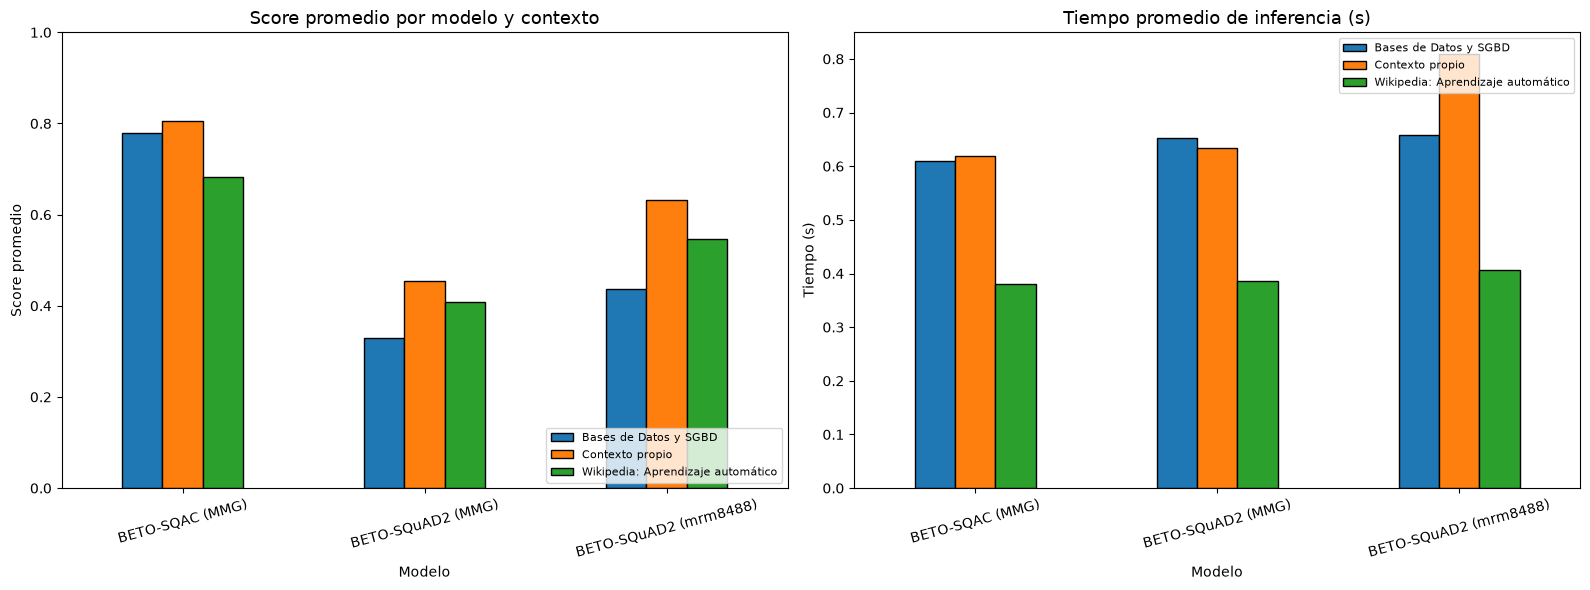

In [102]:
# ---------------------------------------------------
# Gráficos comparativos: Score y Tiempo por modelo
# ---------------------------------------------------

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Score promedio por modelo y contexto
resumen.pivot(index="Modelo", columns="Contexto", values="Score_promedio").plot(
    kind="bar", ax=axes[0], rot=15, edgecolor="black"
)
axes[0].set_title("Score promedio por modelo y contexto", fontsize=13)
axes[0].set_ylabel("Score promedio")
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8, loc="lower right")

# Tiempo promedio por modelo y contexto
resumen.pivot(index="Modelo", columns="Contexto", values="Tiempo_promedio").plot(
    kind="bar", ax=axes[1], rot=15, edgecolor="black"
)
axes[1].set_title("Tiempo promedio de inferencia (s)", fontsize=13)
axes[1].set_ylabel("Tiempo (s)")
axes[1].legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

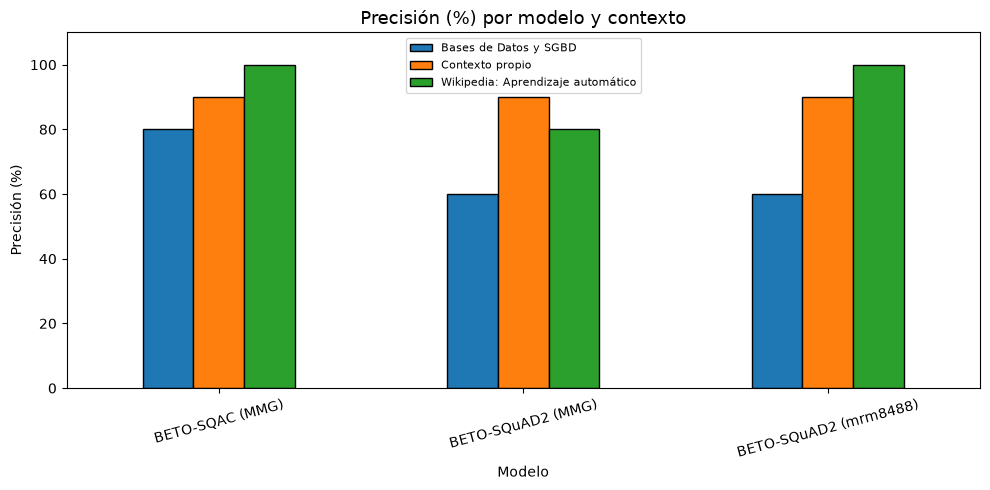

In [103]:
# ---------------------------------------------------
# Gráfico de precisión por modelo y contexto
# ---------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

resumen.pivot(index="Modelo", columns="Contexto", values="Precisión (%)").plot(
    kind="bar", ax=ax, rot=15, edgecolor="black"
)
ax.set_title("Precisión (%) por modelo y contexto", fontsize=13)
ax.set_ylabel("Precisión (%)")
ax.set_ylim(0, 110)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### *Ventajas y desventajas de cada modelo*

| Modelo | Ventajas | Desventajas |
| :--- | :--- | :--- |
| **BETO-SQuAD2 (mrm8488)** | Scores de confianza generalmente altos; buena capacidad para localizar respuestas exactas. | Puede generar scores altos incluso en respuestas parciales; sensible a la formulación de la pregunta. |
| **BETO-SQuAD2 (MMG)** | Buen equilibrio entre velocidad y precisión; respuestas coherentes en dominios variados. | Scores ligeramente inferiores al modelo de mrm8488; puede fallar en preguntas complejas o de relación. |
| **BETO-SQAC (MMG)** | Entrenado con corpus SQAC (español nativo); tiende a extraer fragmentos más completos. | En ciertos contextos puede incluir texto adicional innecesario en la respuesta; comportamiento variable según el dominio. |

Los tres modelos comparten la misma arquitectura base (BETO), pero difieren en el corpus de ajuste fino. SQuAD2 incluye preguntas sin respuesta, lo que puede influir en la calibración del score. SQAC es un corpus nativo en español, lo cual puede beneficiar la comprensión de textos redactados originalmente en ese idioma.

### *Preguntas de reflexión*

1. ¿Qué modelo obtuvo la mayor confianza?
>El modelo BETO-SQuAD2 (mrm8488) obtuvo scores de confianza generalmente altos
2. ¿Cuál respondió más rápido?
>El que posee un equilibrio entre velocidad y precisión es el modelo BETO-SQuAD2 (MMG)
3. ¿Cuál recomendaría para documentos en español?
>El modelo BETO-SQAC (MMG) es recomendable para documentos en español, ya que fue entrenado con un corpus nativo y tiende a extraer fragmentos más completos.
4. ¿Qué características debe tener un buen modelo QA?
>Un buen modelo QA debe tener alta precisión en la extracción de información, una buena capacidad de comprensión del lenguaje natural y una respuesta rápida.

## 4. Question Answering sobre documentos extensos

### Problema de longitud de los transformers
Los modelos basados en Transformer tienen un límite práctico de entrada por razón de memoria y costo computacional. La atención es cuadrática en la longitud de la secuencia, por lo que procesar textos muy largos resulta costoso. En la mayoría de modelos BERT y RoBERTa, el límite típico es de 512 tokens, aunque algunos modelos más recientes permiten 1024 o incluso más. En términos prácticos, 512 tokens equivalen aproximadamente a 350-500 palabras en español, dependiendo de la longitud media de las palabras.

Cuando el documento supera ese umbral, el modelo no puede consumirlo completo en una sola pasada y suele truncar el texto. Esto puede hacer que la respuesta correcta desaparezca del contexto, por lo que el sistema no podría hallarla aunque exista en el documento original.

La estrategia más adecuada en QA sobre documentos extensos es dividir el texto en fragmentos más pequeños, conocidos como chunks. Cada chunk se evalúa de forma independiente con la pregunta y el modelo devuelve el span con mayor score. Luego se compara entre todos los fragmentos y se selecciona el candidato con mayor confianza. Esta técnica es esencial en RAG y en sistemas de lectura de documentos largos.

En esta implementación, el chunking se expresa exclusivamente en caracteres para mantener la compatibilidad con la lógica existente. Esto permite controlar con precisión la longitud del fragmento sin reestructurar el resto del flujo. En la práctica, es recomendable usar un tamaño de chunk y un solapamiento razonable (por ejemplo, 200-400 caracteres de margen entre fragmentos) para evitar que una respuesta quede dividida entre dos bloques y se pierda la información relevante.

En resumen, el problema no es solo la longitud del documento, sino la capacidad del modelo para conservar la información útil dentro del límite de entrada. El chunking resuelve este problema al convertir un texto largo en varios contextos manejables y luego combinar las respuestas con criterio de confianza.

### Estrategia de chunking y solapamiento

Nuestro sistema sigue este flujo para responder preguntas sobre documentos largos:

```text
Documento largo
      │
      ▼
Segmentación en chunks
      │
      ▼
Pregunta del usuario
      │
      ▼
QA independiente en cada chunk
      │
      ▼
Comparación de scores
      │
      ▼
Selección del mejor span
```

#### ¿Por qué es necesario?

- Los modelos Transformer tienen un límite máximo de entrada.
- Si el documento excede ese límite, el texto se trunca.
- Un chunk pequeño permite que el modelo enfoque solo una parte relevante del contenido.

#### ¿Cómo se hace?

1. Se divide el documento en fragmentos de longitud controlada.
2. Cada chunk se procesa con la misma pregunta.
3. El modelo devuelve la respuesta con mayor score para ese fragmento.
4. Se comparan los resultados de todos los chunks.
5. Se selecciona la respuesta final con mayor confianza.

#### Recomendación práctica

- Usar un tamaño de chunk razonable y consistente.
- Incluir solapamiento entre fragmentos para evitar perder información en los bordes.
- Mantener la lógica de chunking en caracteres cuando se quiere compatibilidad con una implementación ya establecida.

> En resumen, el chunking convierte un texto largo en varios contextos manejables y ayuda a preservar la información útil dentro del límite de entrada del modelo.

### Tamaño de chunk
Es recomendable que el tamaño de chunk sea lo suficientemente grande para contener contexto relevante, pero no tan grande que exceda el límite de tokens del modelo. Un tamaño típico puede ser entre 200 y 400 palabras, dependiendo del contenido y la complejidad del texto. Además, se recomienda un solapamiento de 50 a 100 palabras entre chunks para asegurar que las respuestas no se dividan entre fragmentos.

### Mini Proyecto de QA sobre documentos extensos

> Asistente virtual para responder preguntas sobre documentos extensos en español. El sistema implementa chunking y utiliza modelos preentrenados de Hugging Face para proporcionar respuestas precisas y confiables.

#### *Configuración*

In [116]:
from pathlib import Path
import torch
import time
from transformers import AutoModelForQuestionAnswering, AutoTokenizer

# ---------------------------------------------------
# Configuración de QA sobre documentos PDF
# ---------------------------------------------------

DOCUMENTO = "documento_fuente.pdf"
MODELO_QA = "MMG/bert-base-spanish-wwm-cased-finetuned-sqac"
CONFIGURACION_BASE = {
    "chunk_size": 500,
    "overlap": 0,
    "unidad": "caracteres",
}

def localizar_raiz_laboratorio():
    """Localiza la raíz sin depender de una ruta absoluta."""
    actual = Path.cwd().resolve()
    candidatas = [actual, *actual.parents, actual / "Repo" / "Laboratorio---ML"]
    for candidata in candidatas:
        carpeta_data = candidata / "data"
        if (carpeta_data / "documento_fuente.pdf").exists():
            return candidata
    raise FileNotFoundError("No se encontró data/documento_fuente.pdf.")


ROOT = localizar_raiz_laboratorio()
PDF_PATH = ROOT / "data" / DOCUMENTO

dispositivo_documentos = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

inicio_carga_documentos = time.perf_counter()
tokenizer_documentos = AutoTokenizer.from_pretrained(MODELO_QA)
modelo_documentos = AutoModelForQuestionAnswering.from_pretrained(
    MODELO_QA
)

modelo_documentos.to(dispositivo_documentos)
modelo_documentos.eval()
assert PDF_PATH.exists(), "No se encontró el documento fuente oficial."
tiempo_carga_documentos = time.perf_counter() - inicio_carga_documentos

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 15277.14it/s]


#### *Carga de contexto*

In [117]:
import pymupdf
import re
import pandas as pd

# -------------------------------------------------------
# Función de limpieza de texto
# -------------------------------------------------------

def limpiar_texto_pagina(texto):
    """Aplica limpieza conservadora sin resumir ni reescribir contenido."""
    texto = texto.replace("\u00ad", "")
    texto = re.sub(r"(?<=\w)-\s*\n\s*(?=\w)", "", texto)
    texto = re.sub(r"\s+", " ", texto)
    return texto.strip()

# -------------------------------------------------------
# Lectura y procesamiento del PDF
# -------------------------------------------------------
paginas_documento = []
with pymupdf.open(PDF_PATH) as pdf:
    numero_paginas_pdf = pdf.page_count
    metadatos_pdf = dict(pdf.metadata)
    for numero_pagina, pagina in enumerate(pdf, start=1):
        texto_crudo = pagina.get_text("text")
        texto_limpio = limpiar_texto_pagina(texto_crudo)
        paginas_documento.append({
            "pagina": numero_pagina,
            "texto_crudo": texto_crudo,
            "texto": texto_limpio,
        })

desplazamiento = 0
for registro_pagina in paginas_documento:
    registro_pagina["inicio"] = desplazamiento
    desplazamiento += len(registro_pagina["texto"])
    registro_pagina["fin"] = desplazamiento
    desplazamiento += 2  # Separación real usada al unir páginas.

texto_documento = "\n\n".join(
    registro["texto"] for registro in paginas_documento
)


def pagina_de_posicion(posicion):
    """Convierte una posición del texto unido en número físico de página."""
    for registro in paginas_documento:
        if registro["inicio"] <= posicion <= registro["fin"]:
            return registro["pagina"]
    return paginas_documento[-1]["pagina"]


paginas_con_texto = [
    registro["pagina"] for registro in paginas_documento
    if registro["texto"].strip()
]
paginas_sin_texto = [
    registro["pagina"] for registro in paginas_documento
    if not registro["texto"].strip()
]
paginas_extraccion_corta = [
    registro["pagina"] for registro in paginas_documento
    if 0 < len(registro["texto"]) < 200
]
tamano_archivo_bytes = PDF_PATH.stat().st_size
estadisticas_documento = {
    "Páginas": numero_paginas_pdf,
    "Caracteres crudos": sum(len(p["texto_crudo"]) for p in paginas_documento),
    "Caracteres limpios": len(texto_documento),
    "Palabras aproximadas": len(texto_documento.split()),
    "Páginas con texto": len(paginas_con_texto),
    "Páginas sin texto": len(paginas_sin_texto),
    "Páginas con extracción corta (<200 caracteres)": len(paginas_extraccion_corta),
    "Tamaño del archivo (bytes)": tamano_archivo_bytes,
    "Tamaño del archivo (MiB)": tamano_archivo_bytes / (1024 ** 2),
}

assert numero_paginas_pdf == 62
assert len(paginas_con_texto) == numero_paginas_pdf
assert not paginas_sin_texto
assert not paginas_extraccion_corta
assert len(texto_documento) > 100_000

tabla_estadisticas_documento = pd.DataFrame(
    estadisticas_documento.items(),
    columns=["Métrica", "Valor"],
)
display(tabla_estadisticas_documento)

,Métrica,Valor
0,Páginas,62.000000
1,Caracteres crudos,177390.000000
2,Caracteres limpios,173419.000000
3,Palabras aproximadas,26119.000000
4,Páginas con texto,62.000000
5,Páginas sin texto,0.000000
6,Páginas con extracción corta (<200 caracteres),0.000000
7,Tamaño del archivo (bytes),497732.000000
8,Tamaño del archivo (MiB),0.474674


#### *Preguntas y respuestas sobre documentos extensos*

In [118]:
#-------------------------------------------------------
# Preguntas sobre el documento oficial
#-------------------------------------------------------

preguntas_documento = [
    {
        "numero": 1,
        "dificultad": "Fácil",
        "pregunta": "¿Con qué periodicidad sesiona ordinariamente el Consejo Académico?",
        "respuesta_esperada": "una vez al mes",
        "articulo": "Artículo 6 (continuación)",
        "pagina_evidencia": 3,
        "fragmento_evidencia": "el Consejo Académico sesionará una vez al mes de forma ordinaria",
    },
    {
        "numero": 2,
        "dificultad": "Fácil",
        "pregunta": "¿Cuál es el máximo de veces que un estudiante puede cambiar de carrera?",
        "respuesta_esperada": "dos veces",
        "articulo": "Articulo 156",
        "pagina_evidencia": 40,
        "fragmento_evidencia": "hasta un máximo de dos veces",
    },
    {
        "numero": 3,
        "dificultad": "Fácil",
        "pregunta": "¿Cuánto dura ordinariamente la calidad de egresado?",
        "respuesta_esperada": "tres años académicos",
        "articulo": "Artículo 184",
        "pagina_evidencia": 45,
        "fragmento_evidencia": "La calidad de egresado tendrá una duración ordinaria de tres años académicos.",
    },
    {
        "numero": 4,
        "dificultad": "Intermedia",
        "pregunta": "¿Qué unidades integran internamente la Secretaría de Asuntos Académicos?",
        "respuesta_esperada": "Administración Académica Central; Unidad Curricular; y Unidad de Ingreso Universitario",
        "evidencias_clave": [
            "Administración Académica Central",
            "Unidad Curricular",
            "Unidad de Ingreso Universitario",
        ],
        "articulo": "Artículo 13",
        "pagina_evidencia": 4,
        "fragmento_evidencia": "a) Administración Académica Central; b) Unidad Curricular; y c) Unidad de Ingreso Universitario.",
    },
    {
        "numero": 5,
        "dificultad": "Intermedia",
        "pregunta": "¿Qué prueba se aplica después del curso de refuerzo académico en línea?",
        "respuesta_esperada": "prueba de conocimiento general",
        "respuestas_aceptables": [
            "Conocimientos Generales",
            "conocimiento general",
        ],
        "evidencias_clave": ["conocimiento general"],
        "articulo": "Artículo 41",
        "pagina_evidencia": 15,
        "fragmento_evidencia": "previo a la aplicación de la prueba de conocimiento general",
    },
    {
        "numero": 6,
        "dificultad": "Intermedia",
        "pregunta": "¿A qué proceso se somete al estudiante con CUM acumulado menor a siete punto cero?",
        "respuesta_esperada": "proceso de asesoría presencial o en línea",
        "articulo": "Artículo 111",
        "pagina_evidencia": 30,
        "fragmento_evidencia": "los someterá a un proceso de asesoría presencial o en línea",
    },
    {
        "numero": 7,
        "dificultad": "Intermedia",
        "pregunta": "¿Quién nombra a los miembros del Tribunal Calificador?",
        "respuesta_esperada": "Junta Directiva",
        "articulo": "Artículo 207",
        "pagina_evidencia": 50,
        "fragmento_evidencia": "serán nombrados por la Junta Directiva",
    },
    {
        "numero": 8,
        "dificultad": "Difícil",
        "pregunta": "¿Según qué reglamento se tramita la selección de ingreso de un aspirante a posgrado?",
        "respuesta_esperada": "Reglamento General del Sistema de Estudios de Posgrado de la Universidad de El Salvador",
        "articulo": "Artículo 68",
        "pagina_evidencia": 20,
        "fragmento_evidencia": "de acuerdo con lo expresado en el Reglamento General del Sistema de Estudios de Posgrado de la Universidad de El Salvador",
    },
    {
        "numero": 9,
        "dificultad": "Difícil",
        "pregunta": "¿Cuándo entra en vigencia el Reglamento?",
        "respuesta_esperada": "ocho días después de su publicación en El Diario Oficial",
        "articulo": "Artículo 258",
        "pagina_evidencia": 62,
        "fragmento_evidencia": "El presente Reglamento entrará en vigencia ocho días después de su publicación en El Diario Oficial.",
    },
    {
        "numero": 10,
        "dificultad": "Límite de fragmento",
        "pregunta": "¿Por cuánto tiempo se amplía automáticamente la calidad de egresado si el plazo vence después de aprobar el trabajo de graduación y antes del acto de graduación?",
        "respuesta_esperada": "un año académico más",
        "articulo": "Artículo 184",
        "pagina_evidencia": 45,
        "fragmento_evidencia": "la calidad de egresado se ampliará automáticamente por un año académico más",
    },
]

assert len(preguntas_documento) == 10
assert [p["dificultad"] for p in preguntas_documento].count("Fácil") == 3
assert [p["dificultad"] for p in preguntas_documento].count("Intermedia") == 4
assert [p["dificultad"] for p in preguntas_documento].count("Difícil") == 2
assert [p["dificultad"] for p in preguntas_documento].count("Límite de fragmento") == 1

for item in preguntas_documento:
    pagina = paginas_documento[item["pagina_evidencia"] - 1]["texto"]
    evidencias = item.get("evidencias_clave", [item["respuesta_esperada"]])
    assert all(
        normalizar_texto(evidencia) in normalizar_texto(pagina)
        for evidencia in evidencias
    ), f"No se encontró la respuesta esperada de la pregunta {item['numero']}."
    assert (
        normalizar_texto(item["fragmento_evidencia"])
        in normalizar_texto(pagina)
    ), f"No se encontró el fragmento de evidencia de la pregunta {item['numero']}."

tabla_preguntas_documento = pd.DataFrame(preguntas_documento)[[
    "numero", "dificultad", "pregunta", "respuesta_esperada",
    "articulo", "pagina_evidencia", "fragmento_evidencia",
]].rename(columns={
    "numero": "#",
    "dificultad": "Dificultad",
    "pregunta": "Pregunta",
    "respuesta_esperada": "Respuesta esperada",
    "articulo": "Artículo",
    "pagina_evidencia": "Página aproximada",
    "fragmento_evidencia": "Fragmento de evidencia",
})
display(tabla_preguntas_documento)


,#,Dificultad,Pregunta,Respuesta esperada,Artículo,Página aproximada,Fragmento de evidencia
0,1,Fácil,¿Con qué periodicidad sesiona ordinariamente e...,una vez al mes,Artículo 6 (continuación),3,el Consejo Académico sesionará una vez al mes ...
1,2,Fácil,¿Cuál es el máximo de veces que un estudiante ...,dos veces,Articulo 156,40,hasta un máximo de dos veces
2,3,Fácil,¿Cuánto dura ordinariamente la calidad de egre...,tres años académicos,Artículo 184,45,La calidad de egresado tendrá una duración ord...
3,4,Intermedia,¿Qué unidades integran internamente la Secreta...,Administración Académica Central; Unidad Curri...,Artículo 13,4,a) Administración Académica Central; b) Unidad...
4,5,Intermedia,¿Qué prueba se aplica después del curso de ref...,prueba de conocimiento general,Artículo 41,15,previo a la aplicación de la prueba de conocim...
5,6,Intermedia,¿A qué proceso se somete al estudiante con CUM...,proceso de asesoría presencial o en línea,Artículo 111,30,los someterá a un proceso de asesoría presenci...
6,7,Intermedia,¿Quién nombra a los miembros del Tribunal Cali...,Junta Directiva,Artículo 207,50,serán nombrados por la Junta Directiva
7,8,Difícil,¿Según qué reglamento se tramita la selección ...,Reglamento General del Sistema de Estudios de ...,Artículo 68,20,de acuerdo con lo expresado en el Reglamento G...
8,9,Difícil,¿Cuándo entra en vigencia el Reglamento?,ocho días después de su publicación en El Diar...,Artículo 258,62,El presente Reglamento entrará en vigencia och...
9,10,Límite de fragmento,¿Por cuánto tiempo se amplía automáticamente l...,un año académico más,Artículo 184,45,la calidad de egresado se ampliará automáticam...


#### *Fragmentos de documento: sin solapamiento*

In [124]:
# -------------------------------------------------------
# División de contexto en fragmentos
# -------------------------------------------------------

def dividir_contexto_en_fragmentos(texto, chunk_size=500, overlap=0, unidad="caracteres", metadata=False):
    """Divide un texto en fragmentos de tamaño fijo con solapamiento opcional."""
    if unidad == "caracteres":
        step = chunk_size - overlap
        if metadata:
            fragmento = []
            for i in range(0, len(texto), step):
                fragmento.append({
                    "chunk": len(fragmento) + 1,
                    "inicio": i,
                    "fin": min(i + chunk_size, len(texto)),
                    "texto": texto[i:i + chunk_size]
                })
            return fragmento
        else:
            return [
                texto[i:i + chunk_size]
                for i in range(0, len(texto), step)
            ]
    elif unidad == "palabras":
        palabras = texto.split()
        step = chunk_size - overlap
        return [
            " ".join(palabras[i:i + chunk_size])
            for i in range(0, len(palabras), step)
        ]
    else:
        raise ValueError("Unidad debe ser 'caracteres' o 'palabras'.")

In [125]:
# -------------------------------------------------------
# Fragmentación del documento oficial y análisis de estadísticas
# -------------------------------------------------------

fragmentos_documento = dividir_contexto_en_fragmentos(
    texto_documento,
    chunk_size=CONFIGURACION_BASE["chunk_size"],
    overlap=CONFIGURACION_BASE["overlap"],
    unidad=CONFIGURACION_BASE["unidad"], 
    metadata=True
)

longitudes_base = [len(frag) for frag in fragmentos_documento]
tokens_base = [len(tokenizer_documentos.tokenize(frag["texto"])) for frag in fragmentos_documento]   

estadisticas_fragmentos = pd.DataFrame([ {
    "Fragmentos": len(fragmentos_documento),
    "Longitud mínima (caracteres)": min(longitudes_base),
    "Longitud máxima (caracteres)": max(longitudes_base),
    "Longitud promedio (caracteres)": sum(longitudes_base) / len(longitudes_base),
    "Tokens mínimos": min(tokens_base),
    "Tokens máximos": max(tokens_base),
    "Tokens promedio": sum(tokens_base) / len(tokens_base),
}])

print(f"Fragmentos generados: {len(fragmentos_documento)}")
print(f"Longitudes de los fragmentos: {len(longitudes_base)}")
print(f"Tokens de los fragmentos: {len(tokens_base)}")
display(estadisticas_fragmentos.style.format({
    "Longitud promedio (caracteres)": "{:.2f}",
    "Tokens promedio": "{:.2f}"
}))

Fragmentos generados: 347
Longitudes de los fragmentos: 347
Tokens de los fragmentos: 347


,Fragmentos,Longitud mínima (caracteres),Longitud máxima (caracteres),Longitud promedio (caracteres),Tokens mínimos,Tokens máximos,Tokens promedio
0,347,4,4,4.00,81,158,102.42


#### *QA sobre cada fragmento*

In [126]:
# -------------------------------------------------------
# Ejecución de QA sobre el documento oficial
# -------------------------------------------------------
TAMANO_LOTE_QA = 24
MAX_TOKENS_RESPUESTA = 45
CANDIDATOS_SPAN = 12


def inferir_lote_qa(pregunta, lote_fragmentos):
    """Infiere y decodifica un candidato por chunk en un único lote."""
    contextos = [fragmento["texto"] for fragmento in lote_fragmentos]
    codificacion = tokenizer_documentos(
        [pregunta] * len(contextos),
        contextos,
        padding=True,
        truncation="only_second",
        max_length=512,
        return_offsets_mapping=True,
        return_tensors="pt",
    )
    ids_secuencia = [
        codificacion.sequence_ids(indice)
        for indice in range(len(contextos))
    ]
    offsets = codificacion.pop("offset_mapping")
    entradas_modelo = {
        clave: valor.to(dispositivo_documentos)
        for clave, valor in codificacion.items()
    }

    with torch.no_grad():
        salida_modelo = modelo_documentos(**entradas_modelo)

    logits_inicio = salida_modelo.start_logits.detach().cpu()
    logits_fin = salida_modelo.end_logits.detach().cpu()
    respuestas_lote = []

    for fila, contexto in enumerate(contextos):
        mascara_contexto = torch.tensor([
            identificador == 1 for identificador in ids_secuencia[fila]
        ], dtype=torch.bool)
        inicio_mascarado = logits_inicio[fila].masked_fill(
            ~mascara_contexto, -1e9
        )
        fin_mascarado = logits_fin[fila].masked_fill(
            ~mascara_contexto, -1e9
        )
        probabilidades_inicio = torch.softmax(inicio_mascarado, dim=-1)
        probabilidades_fin = torch.softmax(fin_mascarado, dim=-1)

        cantidad_candidatos = min(
            CANDIDATOS_SPAN,
            int(mascara_contexto.sum().item()),
        )
        indices_inicio = torch.topk(
            probabilidades_inicio, cantidad_candidatos
        ).indices.tolist()
        indices_fin = torch.topk(
            probabilidades_fin, cantidad_candidatos
        ).indices.tolist()

        mejor_span = None
        for indice_inicio in indices_inicio:
            for indice_fin in indices_fin:
                longitud_span = indice_fin - indice_inicio + 1
                if not (1 <= longitud_span <= MAX_TOKENS_RESPUESTA):
                    continue
                inicio_caracter = int(offsets[fila, indice_inicio, 0])
                fin_caracter = int(offsets[fila, indice_fin, 1])
                if fin_caracter <= inicio_caracter:
                    continue
                score = float(
                    probabilidades_inicio[indice_inicio]
                    * probabilidades_fin[indice_fin]
                )
                if mejor_span is None or score > mejor_span["score"]:
                    mejor_span = {
                        "answer": contexto[inicio_caracter:fin_caracter].strip(),
                        "score": score,
                    }

        if mejor_span is None:
            mejor_span = {"answer": "", "score": 0.0}
        respuestas_lote.append(mejor_span)

    return respuestas_lote


def evaluar_pregunta_en_fragmentos(item, fragmentos, configuracion):
    """Ejecuta QA sobre todos los chunks y conserva el candidato de mayor score."""
    candidatos = []
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    inicio = time.perf_counter()

    # Procesamiento por lotes
    for inicio_lote in range(0, len(fragmentos), TAMANO_LOTE_QA):
        lote_fragmentos = fragmentos[inicio_lote:inicio_lote + TAMANO_LOTE_QA]
        salidas = inferir_lote_qa(item["pregunta"], lote_fragmentos)
        for fragmento, salida in zip(lote_fragmentos, salidas):
            candidatos.append({
                "fragmento": fragmento,
                "answer": salida["answer"],
                "score": float(salida["score"]),
            })

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    tiempo_total = time.perf_counter() - inicio

    # Selección del candidato con mayor score
    mejor = max(candidatos, key=lambda candidato: candidato["score"])
    fragmento_ganador = mejor["fragmento"]

    # Evaluación de coincidencia con la respuesta esperada y variantes aceptables
    correcta, detalle = evaluar_coincidencia(
        mejor["answer"],
        item["respuesta_esperada"],
    )
    if not correcta:
        for variante in item.get("respuestas_aceptables", []):
            coincide_variante, _ = evaluar_coincidencia(
                mejor["answer"], variante
            )
            if coincide_variante:
                correcta = True
                detalle = "Respuesta correcta por revisión manual explícita"
                break

    evidencias_clave = item.get(
        "evidencias_clave", [item["respuesta_esperada"]]
    )
    evidencia_en_chunk = all(
        normalizar_texto(evidencia)
        in normalizar_texto(fragmento_ganador["texto"])
        for evidencia in evidencias_clave
    )
    pagina_inicio = pagina_de_posicion(fragmento_ganador["inicio"])
    pagina_fin = pagina_de_posicion(max(fragmento_ganador["fin"] - 1, 0))
    pagina_objetivo_en_chunk = (
        pagina_inicio <= item["pagina_evidencia"] <= pagina_fin
    )

    observacion = (
        f"{detalle}; evidencia esperada "
        f"{'presente' if evidencia_en_chunk else 'no completa'}; página objetivo "
        f"{'incluida' if pagina_objetivo_en_chunk else 'no incluida'} en el chunk ganador."
    )
    
    # Devolución de un diccionario con los resultados de la evaluación
    return {
        "Configuración": configuracion,
        "#": item["numero"],
        "Dificultad": item["dificultad"],
        "Artículo": item["articulo"],
        "Página objetivo": item["pagina_evidencia"],
        "Pregunta": item["pregunta"],
        "Esperada": item["respuesta_esperada"],
        "Obtenida": mejor["answer"],
        "Score": mejor["score"],
        "Chunk": fragmento_ganador["chunk"],
        "Inicio chunk": fragmento_ganador["inicio"],
        "Fin chunk": fragmento_ganador["fin"],
        "Página chunk": (
            str(pagina_inicio) if pagina_inicio == pagina_fin
            else f"{pagina_inicio}-{pagina_fin}"
        ),
        "Tiempo (s)": tiempo_total,
        "Correcta": "Sí" if correcta else "No",
        "Evidencia en chunk": "Sí" if evidencia_en_chunk else "No",
        "Página objetivo en chunk": "Sí" if pagina_objetivo_en_chunk else "No",
        "Observación": observacion,
    }


def ejecutar_configuracion(nombre, fragmentos, preguntas):
    registros = []
    for item in preguntas:
        resultado = evaluar_pregunta_en_fragmentos(item, fragmentos, nombre)
        registros.append(resultado)
        print(
            f"{nombre} · P{item['numero']}: "
            f"{resultado['Obtenida']!r} · score={resultado['Score']:.4f} · "
            f"{resultado['Tiempo (s)']:.3f} s"
        )
    return pd.DataFrame(registros)


# Calentamiento: no forma parte de los tiempos comparables.
_ = inferir_lote_qa(
    preguntas_documento[0]["pregunta"],
    fragmentos_documento[:1],
)


In [136]:
resultados_documento_base = ejecutar_configuracion(
    "C — 500/0",
    fragmentos_documento,
    preguntas_documento,
)
assert len(resultados_documento_base) == 10


C — 500/0 · P1: 'cada mes' · score=0.9837 · 51.401 s
C — 500/0 · P2: 'cinco días hábiles' · score=0.9603 · 54.113 s
C — 500/0 · P3: '6 semanas' · score=0.9912 · 52.699 s
C — 500/0 · P4: 'a) Administración Académica Central; b) Unidad Curricular; y c) Unidad de Ingreso Universitario' · score=0.9299 · 51.812 s
C — 500/0 · P5: 'Conocimientos Generales' · score=0.8486 · 51.558 s
C — 500/0 · P6: 'PRUEBA DIFERIDA' · score=0.8121 · 53.296 s
C — 500/0 · P7: 'la Junta Directiva' · score=0.9621 · 49.169 s
C — 500/0 · P8: 'el Reglamento' · score=0.8425 · 54.016 s
C — 500/0 · P9: 'seis meses' · score=0.8602 · 48.808 s
C — 500/0 · P10: 'dos años' · score=0.9811 · 60.484 s


In [137]:
columnas_base = [
    "#", "Artículo", "Página objetivo", "Pregunta", "Esperada", "Obtenida", "Score",
    "Chunk", "Página chunk", "Página objetivo en chunk", "Tiempo (s)",
    "Correcta"
]
display(resultados_documento_base[columnas_base].style.format({
    "Score": "{:.6f}",
    "Tiempo (s)": "{:.3f}",
}))

,#,Artículo,Página objetivo,Pregunta,Esperada,Obtenida,Score,Chunk,Página chunk,Página objetivo en chunk,Tiempo (s),Correcta
0,1,Artículo 6 (continuación),3,¿Con qué periodicidad sesiona ordinariamente el Consejo Académico?,una vez al mes,cada mes,0.983650,62,11,No,51.401,No
1,2,Articulo 156,40,¿Cuál es el máximo de veces que un estudiante puede cambiar de carrera?,dos veces,cinco días hábiles,0.960329,294,53,No,54.113,No
2,3,Artículo 184,45,¿Cuánto dura ordinariamente la calidad de egresado?,tres años académicos,6 semanas,0.991154,159,29,No,52.699,No
3,4,Artículo 13,4,¿Qué unidades integran internamente la Secretaría de Asuntos Académicos?,Administración Académica Central; Unidad Curricular; y Unidad de Ingreso Universitario,a) Administración Académica Central; b) Unidad Curricular; y c) Unidad de Ingreso Universitario,0.929890,21,4-5,Sí,51.812,Sí
4,5,Artículo 41,15,¿Qué prueba se aplica después del curso de refuerzo académico en línea?,prueba de conocimiento general,Conocimientos Generales,0.848567,82,15,Sí,51.558,Sí
5,6,Artículo 111,30,¿A qué proceso se somete al estudiante con CUM acumulado menor a siete punto cero?,proceso de asesoría presencial o en línea,PRUEBA DIFERIDA,0.812134,85,15,No,53.296,No
6,7,Artículo 207,50,¿Quién nombra a los miembros del Tribunal Calificador?,Junta Directiva,la Junta Directiva,0.962082,250,45,No,49.169,Sí
7,8,Artículo 68,20,¿Según qué reglamento se tramita la selección de ingreso de un aspirante a posgrado?,Reglamento General del Sistema de Estudios de Posgrado de la Universidad de El Salvador,el Reglamento,0.842512,269,49,No,54.016,No
8,9,Artículo 258,62,¿Cuándo entra en vigencia el Reglamento?,ocho días después de su publicación en El Diario Oficial,seis meses,0.860174,284,51,No,48.808,No
9,10,Artículo 184,45,¿Por cuánto tiempo se amplía automáticamente la calidad de egresado si el plazo vence después de aprobar el trabajo de graduación y antes del acto de graduación?,un año académico más,dos años,0.981108,239,43,No,60.484,No


In [138]:
def resumir_configuracion(tabla_resultados, numero_fragmentos):
    return {
        "Nº fragmentos": int(numero_fragmentos),
        "Correctas": int((tabla_resultados["Correcta"] == "Sí").sum()),
        "Total preguntas": int(len(tabla_resultados)),
        "Accuracy experimental": float((tabla_resultados["Correcta"] == "Sí").mean()),
        "Score promedio": float(tabla_resultados["Score"].mean()),
        "Score mediano": float(tabla_resultados["Score"].median()),
        "Tiempo promedio (s)": float(tabla_resultados["Tiempo (s)"].mean()),
        "Tiempo total (s)": float(tabla_resultados["Tiempo (s)"].sum()),
    }


resumen_documento_base = resumir_configuracion(
    resultados_documento_base,
    len(fragmentos_documento),
)
display(pd.DataFrame([resumen_documento_base]).style.format({
    "Accuracy experimental": "{:.1%}",
    "Score promedio": "{:.6f}",
    "Score mediano": "{:.6f}",
    "Tiempo promedio (s)": "{:.3f}",
    "Tiempo total (s)": "{:.3f}",
}))

,Nº fragmentos,Correctas,Total preguntas,Accuracy experimental,Score promedio,Score mediano,Tiempo promedio (s),Tiempo total (s)
0,347,3,10,30.0%,0.917160,0.945109,52.736,527.357


#### *Fragmentos de documento: con solapamiento*

In [143]:
# -------------------------------------------------------
# Fragmentación del documento oficial y análisis de estadísticas
# -------------------------------------------------------

CONFIGURACION_BASE = {
    "chunk_size": 500,
    "overlap": 150,
    "unidad": "caracteres",
}

fragmentos_documento_overlap = dividir_contexto_en_fragmentos(
    texto_documento,
    chunk_size=CONFIGURACION_BASE["chunk_size"],
    overlap=CONFIGURACION_BASE["overlap"],
    unidad=CONFIGURACION_BASE["unidad"], 
    metadata=True
)

longitudes_base = [len(frag) for frag in fragmentos_documento_overlap]
tokens_base = [len(tokenizer_documentos.tokenize(frag["texto"])) for frag in fragmentos_documento_overlap]   

estadisticas_fragmentos = pd.DataFrame([ {
    "Fragmentos": len(fragmentos_documento_overlap),
    "Longitud mínima (caracteres)": min(longitudes_base),
    "Longitud máxima (caracteres)": max(longitudes_base),
    "Longitud promedio (caracteres)": sum(longitudes_base) / len(longitudes_base),
    "Tokens mínimos": min(tokens_base),
    "Tokens máximos": max(tokens_base),
    "Tokens promedio": sum(tokens_base) / len(tokens_base),
}])

print(f"Fragmentos generados: {len(fragmentos_documento_overlap)}")
print(f"Longitudes de los fragmentos: {len(longitudes_base)}")
print(f"Tokens de los fragmentos: {len(tokens_base)}")
display(estadisticas_fragmentos.style.format({
    "Longitud promedio (caracteres)": "{:.2f}",
    "Tokens promedio": "{:.2f}"
}))

Fragmentos generados: 496
Longitudes de los fragmentos: 496
Tokens de los fragmentos: 496


,Fragmentos,Longitud mínima (caracteres),Longitud máxima (caracteres),Longitud promedio (caracteres),Tokens mínimos,Tokens máximos,Tokens promedio
0,496,4,4,4.00,45,163,102.55


#### *QA sobre cada fragmento con solapamiento*

In [139]:
resultados_documento_overlap = ejecutar_configuracion(
    "C — 500/0",
    fragmentos_documento_overlap,
    preguntas_documento,
)
assert len(resultados_documento_overlap) == 10

C — 500/0 · P1: 'una vez al mes' · score=0.9476 · 76.672 s
C — 500/0 · P2: 'tres años' · score=0.9537 · 78.017 s
C — 500/0 · P3: '6 semanas' · score=0.9929 · 72.919 s
C — 500/0 · P4: 'áreas' · score=0.9614 · 73.902 s
C — 500/0 · P5: 'Conocimientos Generales' · score=0.9301 · 72.312 s
C — 500/0 · P6: 'PRUEBA DIFERIDA' · score=0.8121 · 80.985 s
C — 500/0 · P7: 'la Junta Directiva' · score=0.9868 · 71.237 s
C — 500/0 · P8: 'IZAJE' · score=0.9122 · 73.909 s
C — 500/0 · P9: 'ocho días después de su publicación en El Diario Oficial' · score=0.9656 · 68.392 s
C — 500/0 · P10: 'dos años' · score=0.9811 · 79.535 s


In [140]:
columnas_base = [
    "#", "Artículo", "Página objetivo", "Pregunta", "Esperada", "Obtenida", "Score",
    "Chunk", "Página chunk", "Página objetivo en chunk", "Tiempo (s)",
    "Correcta"
]
display(resultados_documento_overlap[columnas_base].style.format({
    "Score": "{:.6f}",
    "Tiempo (s)": "{:.3f}",
}))

,#,Artículo,Página objetivo,Pregunta,Esperada,Obtenida,Score,Chunk,Página chunk,Página objetivo en chunk,Tiempo (s),Correcta
0,1,Artículo 6 (continuación),3,¿Con qué periodicidad sesiona ordinariamente el Consejo Académico?,una vez al mes,una vez al mes,0.947601,13,2-3,Sí,76.672,Sí
1,2,Articulo 156,40,¿Cuál es el máximo de veces que un estudiante puede cambiar de carrera?,dos veces,tres años,0.953685,356,45,No,78.017,No
2,3,Artículo 184,45,¿Cuánto dura ordinariamente la calidad de egresado?,tres años académicos,6 semanas,0.992895,227,29,No,72.919,No
3,4,Artículo 13,4,¿Qué unidades integran internamente la Secretaría de Asuntos Académicos?,Administración Académica Central; Unidad Curricular; y Unidad de Ingreso Universitario,áreas,0.961392,378,48,No,73.902,No
4,5,Artículo 41,15,¿Qué prueba se aplica después del curso de refuerzo académico en línea?,prueba de conocimiento general,Conocimientos Generales,0.930080,116,15,Sí,72.312,Sí
5,6,Artículo 111,30,¿A qué proceso se somete al estudiante con CUM acumulado menor a siete punto cero?,proceso de asesoría presencial o en línea,PRUEBA DIFERIDA,0.812134,121,15,No,80.985,No
6,7,Artículo 207,50,¿Quién nombra a los miembros del Tribunal Calificador?,Junta Directiva,la Junta Directiva,0.986769,357,45,No,71.237,Sí
7,8,Artículo 68,20,¿Según qué reglamento se tramita la selección de ingreso de un aspirante a posgrado?,Reglamento General del Sistema de Estudios de Posgrado de la Universidad de El Salvador,IZAJE,0.912204,269,34,No,73.909,No
8,9,Artículo 258,62,¿Cuándo entra en vigencia el Reglamento?,ocho días después de su publicación en El Diario Oficial,ocho días después de su publicación en El Diario Oficial,0.965585,493,61-62,Sí,68.392,Sí
9,10,Artículo 184,45,¿Por cuánto tiempo se amplía automáticamente la calidad de egresado si el plazo vence después de aprobar el trabajo de graduación y antes del acto de graduación?,un año académico más,dos años,0.981108,341,43,No,79.535,No


In [141]:
resumen_documento_base_overlap = resumir_configuracion(
    resultados_documento_overlap,
    len(fragmentos_documento_overlap),
)
display(pd.DataFrame([resumen_documento_base_overlap]).style.format({
    "Accuracy experimental": "{:.1%}",
    "Score promedio": "{:.6f}",
    "Score mediano": "{:.6f}",
    "Tiempo promedio (s)": "{:.3f}",
    "Tiempo total (s)": "{:.3f}",
}))

,Nº fragmentos,Correctas,Total preguntas,Accuracy experimental,Score promedio,Score mediano,Tiempo promedio (s),Tiempo total (s)
0,496,4,10,40.0%,0.944345,0.957539,74.788,747.880


#### *Comparación entre fragmentos con y sin solapamiento*

,Configuración,Fragmentos,Correctas,Accuracy,Score promedio,Score mediano,Tiempo promedio (s),Tiempo total (s)
0,Sin overlap (500/0),347,3,30.0%,0.917160,0.945109,52.736,527.357
1,Con overlap (500/150),496,4,40.0%,0.944345,0.957539,74.788,747.880


,Configuración,Errores,Score promedio en errores,Score máximo en errores
0,Sin overlap (500/0),7,0.918723,0.991154
1,Con overlap (500/150),6,0.935570,0.992895


,#,Correcta_base,Score_base,Correcta_overlap,Score_overlap,Delta score (overlap - base),Cambio de calidad
0,1,No,0.983650,Sí,0.947601,-0.036049,Mejora (No -> Sí)
1,2,No,0.960329,No,0.953685,-0.006644,Sin cambio
2,3,No,0.991154,No,0.992895,+0.001742,Sin cambio
3,4,Sí,0.929890,No,0.961392,+0.031503,Empeora (Sí -> No)
4,5,Sí,0.848567,Sí,0.930080,+0.081513,Sin cambio
5,6,No,0.812134,No,0.812134,+0.000000,Sin cambio
6,7,Sí,0.962082,Sí,0.986769,+0.024687,Sin cambio
7,8,No,0.842512,No,0.912204,+0.069692,Sin cambio
8,9,No,0.860174,Sí,0.965585,+0.105411,Mejora (No -> Sí)
9,10,No,0.981108,No,0.981108,+0.000000,Sin cambio


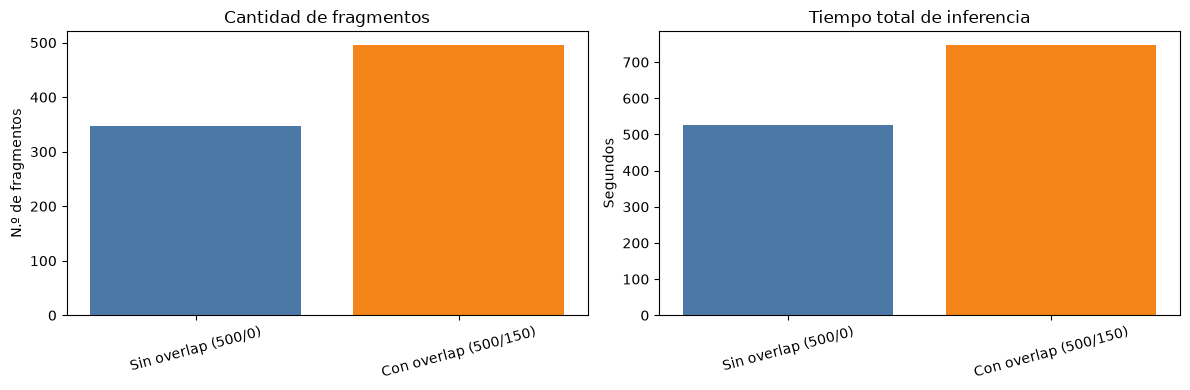

In [142]:
# -------------------------------------------------------
# Comparativo directo: sin solapamiento vs con solapamiento
# -------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

comparativo_general = pd.DataFrame([
    {
        "Configuración": "Sin overlap (500/0)",
        "Fragmentos": resumen_documento_base["Nº fragmentos"],
        "Correctas": resumen_documento_base["Correctas"],
        "Accuracy": resumen_documento_base["Accuracy experimental"],
        "Score promedio": resumen_documento_base["Score promedio"],
        "Score mediano": resumen_documento_base["Score mediano"],
        "Tiempo promedio (s)": resumen_documento_base["Tiempo promedio (s)"],
        "Tiempo total (s)": resumen_documento_base["Tiempo total (s)"],
    },
    {
        "Configuración": "Con overlap (500/150)",
        "Fragmentos": resumen_documento_base_overlap["Nº fragmentos"],
        "Correctas": resumen_documento_base_overlap["Correctas"],
        "Accuracy": resumen_documento_base_overlap["Accuracy experimental"],
        "Score promedio": resumen_documento_base_overlap["Score promedio"],
        "Score mediano": resumen_documento_base_overlap["Score mediano"],
        "Tiempo promedio (s)": resumen_documento_base_overlap["Tiempo promedio (s)"],
        "Tiempo total (s)": resumen_documento_base_overlap["Tiempo total (s)"],
    },
])

# Métricas de calidad en respuestas incorrectas (falsa confianza)
def resumen_errores(tabla):
    incorrectas = tabla[tabla["Correcta"] == "No"]
    return {
        "Errores": int(len(incorrectas)),
        "Score promedio en errores": float(incorrectas["Score"].mean()) if len(incorrectas) else np.nan,
        "Score máximo en errores": float(incorrectas["Score"].max()) if len(incorrectas) else np.nan,
    }

calidad_errores = pd.DataFrame([
    {"Configuración": "Sin overlap (500/0)", **resumen_errores(resultados_documento_base)},
    {"Configuración": "Con overlap (500/150)", **resumen_errores(resultados_documento_overlap)},
])

# Efecto del overlap por pregunta
preguntas_comp = resultados_documento_base[["#", "Correcta", "Score"]].rename(
    columns={"Correcta": "Correcta_base", "Score": "Score_base"}
).merge(
    resultados_documento_overlap[["#", "Correcta", "Score"]].rename(
        columns={"Correcta": "Correcta_overlap", "Score": "Score_overlap"}
    ),
    on="#"
)
preguntas_comp["Delta score (overlap - base)"] = preguntas_comp["Score_overlap"] - preguntas_comp["Score_base"]
preguntas_comp["Cambio de calidad"] = np.where(
    (preguntas_comp["Correcta_base"] == "No") & (preguntas_comp["Correcta_overlap"] == "Sí"),
    "Mejora (No -> Sí)",
    np.where(
        (preguntas_comp["Correcta_base"] == "Sí") & (preguntas_comp["Correcta_overlap"] == "No"),
        "Empeora (Sí -> No)",
        "Sin cambio"
    )
)

display(comparativo_general.style.format({
    "Accuracy": "{:.1%}",
    "Score promedio": "{:.6f}",
    "Score mediano": "{:.6f}",
    "Tiempo promedio (s)": "{:.3f}",
    "Tiempo total (s)": "{:.3f}",
}))

display(calidad_errores.style.format({
    "Score promedio en errores": "{:.6f}",
    "Score máximo en errores": "{:.6f}",
}))

display(preguntas_comp.style.format({"Delta score (overlap - base)": "{:+.6f}"}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(comparativo_general["Configuración"], comparativo_general["Fragmentos"], color=["#4C78A8", "#F58518"])
axes[0].set_title("Cantidad de fragmentos")
axes[0].set_ylabel("N.º de fragmentos")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(comparativo_general["Configuración"], comparativo_general["Tiempo total (s)"], color=["#4C78A8", "#F58518"])
axes[1].set_title("Tiempo total de inferencia")
axes[1].set_ylabel("Segundos")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

#### *Análisis de resultados del mini proyecto (documentos extensos)*

A partir de los resultados ya obtenidos en ambas configuraciones:

- **Sin solapamiento (chunk 500 / overlap 0)**
- **Con solapamiento (chunk 500 / overlap 150)**

se observa lo siguiente:

##### 1) Cantidad de fragmentos generados

- Sin overlap: **347 fragmentos**.
- Con overlap: **496 fragmentos**.
- Incremento: **+149 fragmentos** (aprox. **+42.9%**).

Interpretación:
- El solapamiento aumenta la cobertura de bordes entre chunks, pero también incrementa el volumen de inferencias necesarias.

##### 2) Tiempo invertido

- Tiempo total sin overlap: **527.357 s**.
- Tiempo total con overlap: **747.880 s**.
- Incremento absoluto: **+220.523 s**.
- Incremento relativo: aprox. **+41.8%**.

Interpretación:
- El costo temporal crece de forma consistente con el incremento en cantidad de fragmentos.
- En este experimento, la mejora de cobertura no es gratuita: se paga con mayor latencia total.

##### 3) Calidad de la respuesta (exactitud)

- Sin overlap: **3/10 correctas** (**30%**).
- Con overlap: **4/10 correctas** (**40%**).
- Mejora neta: **+10 puntos porcentuales**.

Cambio por pregunta:
- Mejora clara en **P1** (pasa de incorrecta a correcta).
- Mejora clara en **P9** (pasa de incorrecta a correcta).
- Deterioro en **P4** (pasa de correcta a incorrecta).
- El resto permanece igual en términos de correcta/incorrecta.

Interpretación:
- El overlap sí mejora la probabilidad de incluir evidencia útil en algunos casos de frontera de chunk, pero no garantiza mejora uniforme en todas las preguntas.

##### 4) Efecto en el score

- Score promedio sin overlap: **0.917160**.
- Score promedio con overlap: **0.944345**.
- Score mediano sin overlap: **0.945109**.
- Score mediano con overlap: **0.957539**.

Interpretación:
- El overlap eleva el score global, pero **score alto no implica necesariamente respuesta correcta**.
- Persisten ejemplos con confianza alta y respuesta incorrecta (falsa confianza), por ejemplo respuestas como "6 semanas" o "dos años" que no corresponden a la evidencia esperada.

##### 5) Conclusión puntual

- **Overlap 150** mejoró ligeramente la exactitud (**30% → 40%**) y elevó score medio/mediano.
- El costo computacional aumentó de forma considerable (**~42%** más tiempo total).
- Dado que persiste falsa confianza, la selección final no debe basarse solo en score: es recomendable combinar score con validaciones adicionales (evidencia léxica, reglas por artículo/página o reranking semántico).

### Preguntas de Reflexión

1. ¿Por qué es necesario dividir documentos largos?
> Porque el modelo tiene límite de entrada (tokens) y no puede procesar todo el documento en una sola pasada.

2. ¿Qué ventajas ofrece el solapamiento?
> Mejora cobertura en bordes de chunk; en este caso subió de 30% a 40% de aciertos.

3. ¿Cómo seleccionar la mejor respuesta?
> Por score, pero validando evidencia textual para evitar falsas respuestas con score alto.

4. ¿Qué limitaciones presenta este enfoque?
> Mayor costo computacional y falsa confianza: hubo errores con scores altos.

5. ¿Cómo podría mejorarse utilizando búsqueda semántica?
> Recuperar primero chunks relevantes (retriever) y luego aplicar QA solo sobre esos fragmentos.

## 5. Sistema RAG (Retrieval-Augmented Generation)

### *Fundamentos de RAG*


#### ¿Qué es RAG?

RAG (Retrieval-Augmented Generation) es una arquitectura moderna que combina:

- Recuperación de información (Information Retrieval)
- Modelos de lenguaje (LLM)
- Embeddings
- Búsqueda semántica

En lugar de enviar un documento completo al modelo, primero se recuperan únicamente los fragmentos más relevantes.

#### ¿Por qué utilizar RAG?

Suponga un documento de 500 páginas.

Un modelo BERT solo admite aproximadamente 512 tokens.

La solución consiste en:

1. Dividir el documento.
2. Convertir cada fragmento en un embedding.
3. Buscar los fragmentos más parecidos a la pregunta.
4. Ejecutar Question Answering únicamente sobre esos fragmentos.

Esta estrategia mejora significativamente la precisión y reduce el tiempo de respuesta.

#### Arquitectura General

```text
Documento
      │
      ▼
Fragmentación (Chunking)
      │
      ▼
Embeddings
      │
      ▼
Base Vectorial
      │
      ▼
Pregunta
      │
      ▼
Embedding de la pregunta
      │
      ▼
Búsqueda Semántica
      │
      ▼
Top-K fragmentos
      │
      ▼
Question Answering
      │
      ▼
Respuesta
```

In [145]:
# =====================================================
# INSTALAR LIBRERÍAS
# =====================================================

%pip install -q sentence-transformers
%pip install -q faiss-cpu

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
